In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path 
from tqdm import tqdm 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

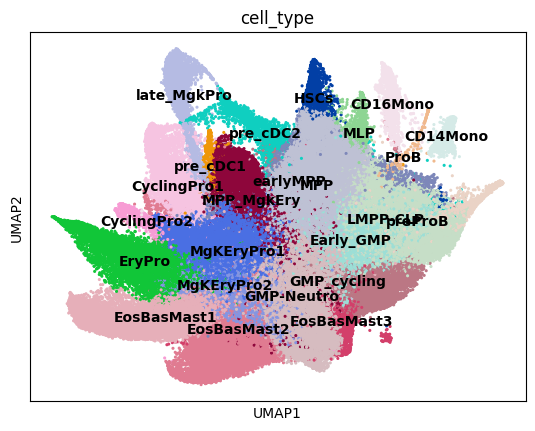

In [4]:
sc.pl.umap(
    adata,
    color="cell_type",
    s=20,
    legend_loc="on data"
)

In [5]:
to_keep = ["CD14Mono",
            "CD16Mono",
            "CyclingPro1",
            "CyclingPro2",
            "EosBasMast1",
            "EosBasMast2",
            "EosBasMast3",
            "EryPro",
            "HSCs",
            "ProB",
            "late_MgkPro",
            'GMP-Neutro',
            'preProB',
            'pre_cDC1']

In [6]:
adata.obs.cell_type.value_counts().loc[to_keep].sort_values(ascending=False)

cell_type
GMP-Neutro     73575
EosBasMast2    31986
EosBasMast1    22697
EryPro         16958
CyclingPro1    10060
late_MgkPro     4470
HSCs            2668
EosBasMast3     1964
preProB         1593
CD16Mono        1213
CyclingPro2      934
pre_cDC1         704
CD14Mono         667
ProB             174
Name: count, dtype: int64

## Check cell type profiles per unique protocol 

In [7]:
adata.obs.columns

Index(['experiment_number', 'replicate', 'date', 'cytometer',
       'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts',
       'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]',
       'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]',
       'source_cell_phenotype', 'total_count_beads',
       'counts_source_cell_phenotype', 'days_of_culture', 'plate',
       'absolute_number_multiplier_[2^n]', 'cytometer_id',
       'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width',
       'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width',
       'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub',
       'leiden_old', 'cell_type'],
      dtype='object')

In [8]:
protocol_columns = ["740-yp_[µm]", 
                   "mtg_[µm]", 
                   "rhflt3l_[ng_ml]", 
                   "gm-csf_[ng_ml]", 
                   "tpo_[ng_ml]",
                   "sr1_[nm]", 
                   "um171_[nm]", 
                   "um729_[µm]", 
                   "scf_[ng_ml]",
                   "butyzamide_[nm]",
                   "retinoic_acid_[µm]",
                   "ldl_[ng_ml]", 
                   "il3_[ng_ml]", 
                   "o2_[%]", 
                   "days_of_culture"]

In [9]:
for p in protocol_columns:
    print(p)
    print(np.array(adata.obs[p].unique()))
    print()

740-yp_[µm]
[5]

mtg_[µm]
[100]

rhflt3l_[ng_ml]
[10]

gm-csf_[ng_ml]
['10' '0' '1']

tpo_[ng_ml]
[2.5  0.   0.5  1.   0.25]

sr1_[nm]
[375 750   0  75]

um171_[nm]
[1120    0  560   70  280]

um729_[µm]
[0.   1.5  0.75]

scf_[ng_ml]
[50  0 10]

butyzamide_[nm]
[  0 100]

retinoic_acid_[µm]
[0 1 5]

ldl_[ng_ml]
[ 0  2 10 50 20  5]

il3_[ng_ml]
[ 0.  10.   5.  20.   2.5]

o2_[%]
[20 10]

days_of_culture
[21 13 14 27 28 36 15]



In [10]:
# Obs 
cell_type_proportions = {cell_type: [] for cell_type in adata.obs.cell_type.unique()}

# X 
obs_protocols = adata.obs.loc[:, protocol_columns].values.astype(float)
X = np.unique(obs_protocols, axis=0)

In [11]:
for unique_protocol in tqdm(X):
    idx = (adata.obs.loc[:, protocol_columns].values.astype(float)==unique_protocol[None, :]).all(1)
    adata_protocol = adata[idx]
    proportions = adata_protocol.obs.cell_type.value_counts()/adata_protocol.shape[0]
    for cell_type in cell_type_proportions: 
        if cell_type in proportions.index.values:
            cell_type_proportions[cell_type].append(proportions[cell_type])
        else:
            cell_type_proportions[cell_type].append(0.0)

100%|██████████| 103/103 [00:46<00:00,  2.22it/s]


In [12]:
proportion_df = pd.DataFrame(cell_type_proportions)

protocol_adata = sc.AnnData(X=np.log1p(X), obs=proportion_df)
protocol_adata.var.index = protocol_columns

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [13]:
argmax_protocols = np.argmax(protocol_adata.obs, axis=0)

In [14]:
adata_argmax = protocol_adata[argmax_protocols]
adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)

/tmp/ipykernel_3168416/824891330.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


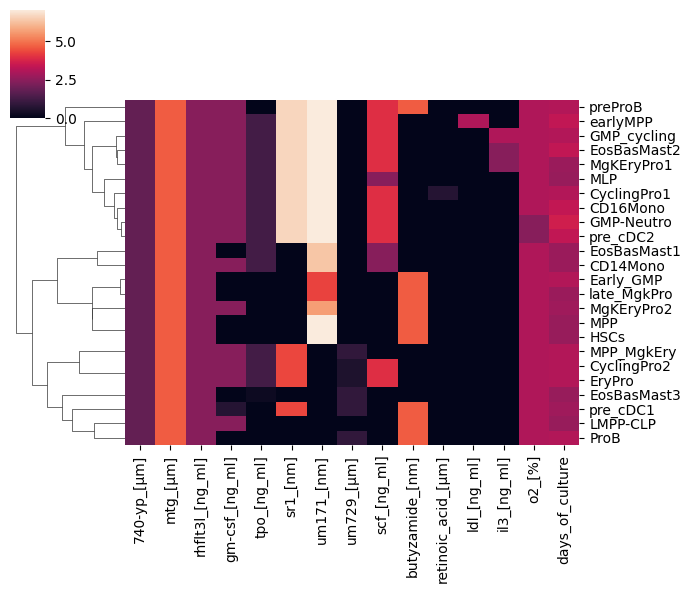

In [15]:
sns.clustermap(
    adata_argmax.X,
    yticklabels=adata_argmax.obs["cell_type"], 
    xticklabels=adata_argmax.var.index, 
    figsize=(7, 6),
    col_cluster=False
)
plt.show()

In [16]:
protocol_adata

AnnData object with n_obs × n_vars = 103 × 15
    obs: 'LMPP-CLP', 'GMP_cycling', 'EosBasMast2', 'MgKEryPro1', 'GMP-Neutro', 'EosBasMast3', 'Early_GMP', 'MPP', 'MgKEryPro2', 'EosBasMast1', 'pre_cDC2', 'preProB', 'MPP_MgkEry', 'pre_cDC1', 'MLP', 'earlyMPP', 'CyclingPro1', 'CyclingPro2', 'CD14Mono', 'HSCs', 'EryPro', 'late_MgkPro', 'CD16Mono', 'ProB'

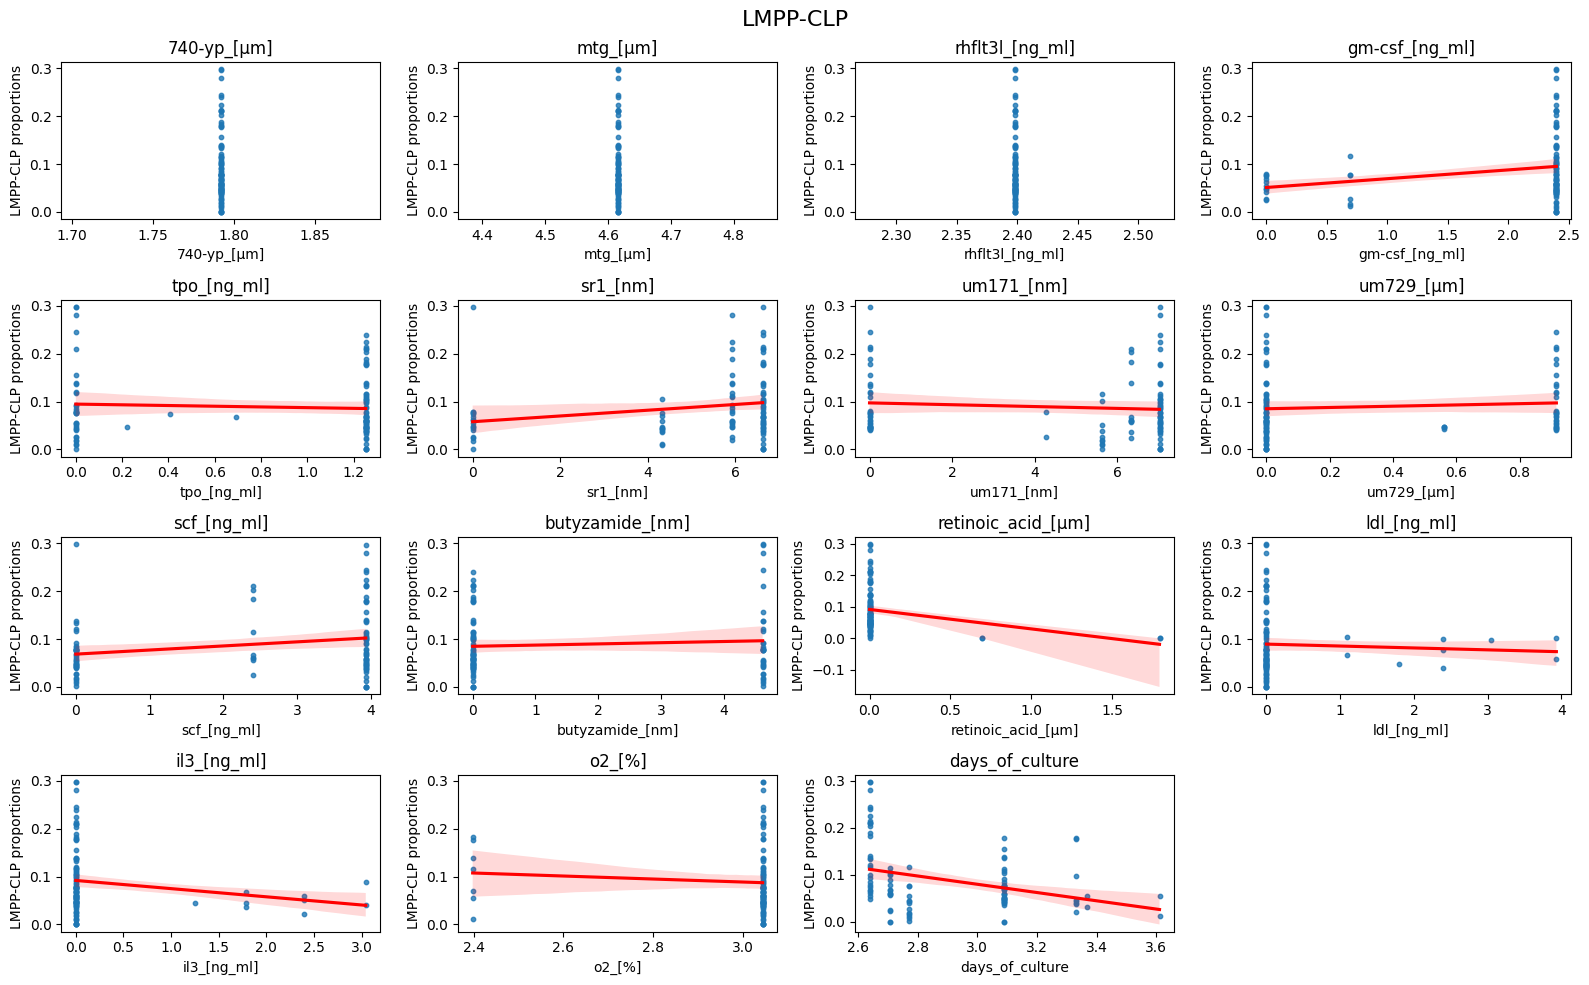

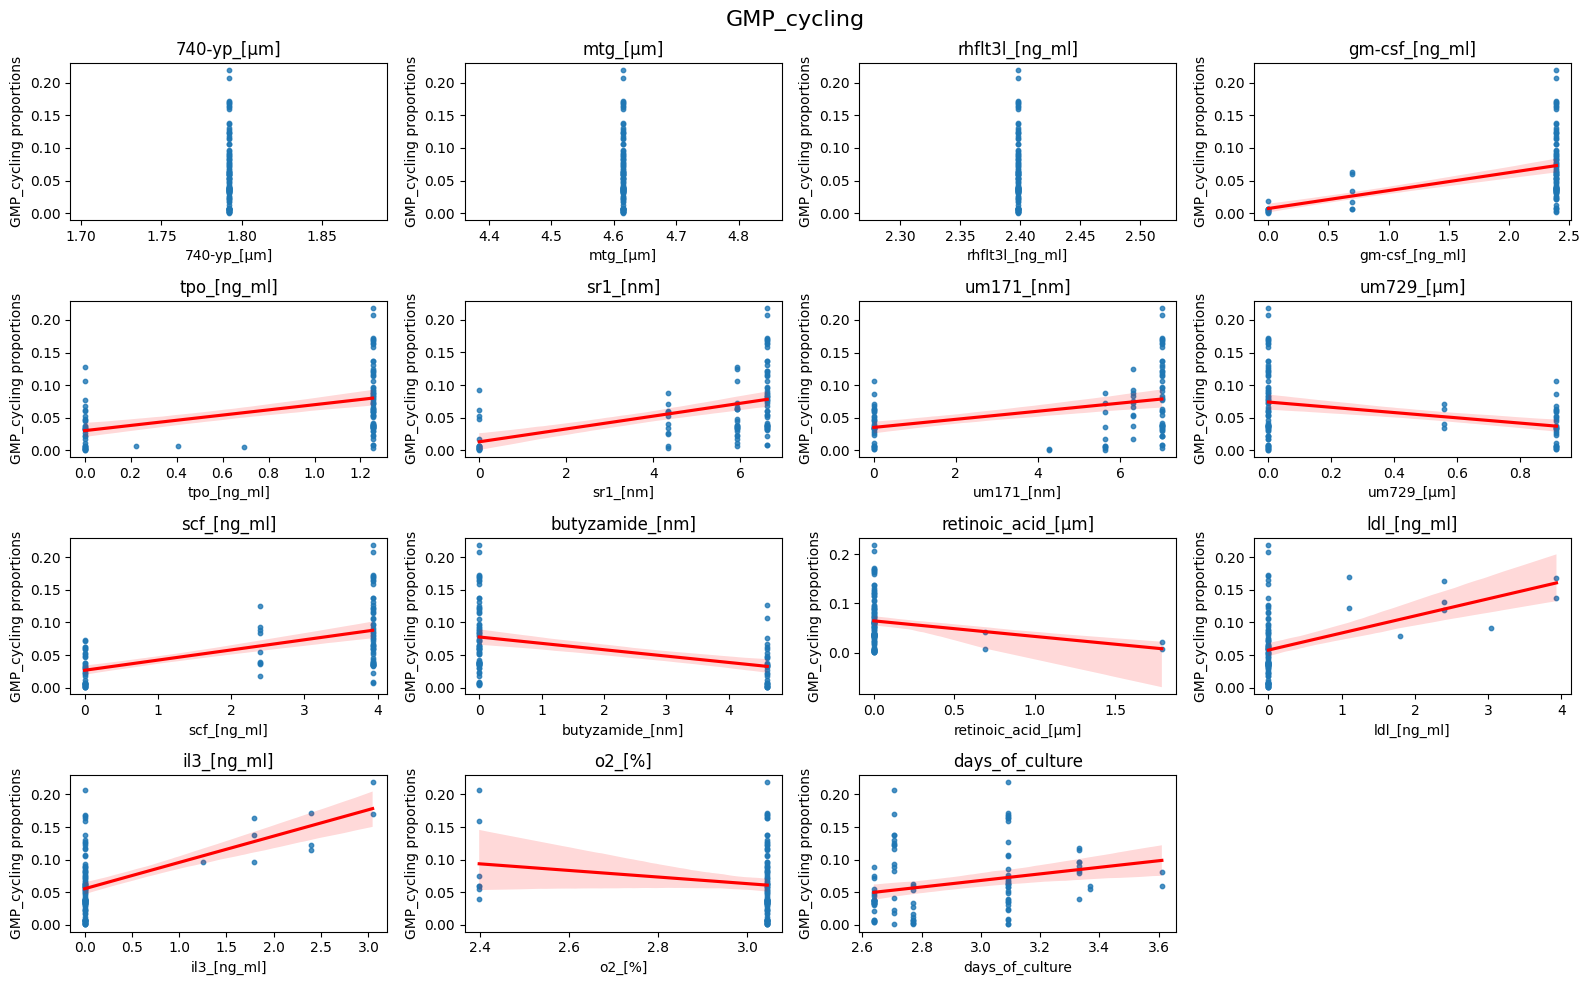

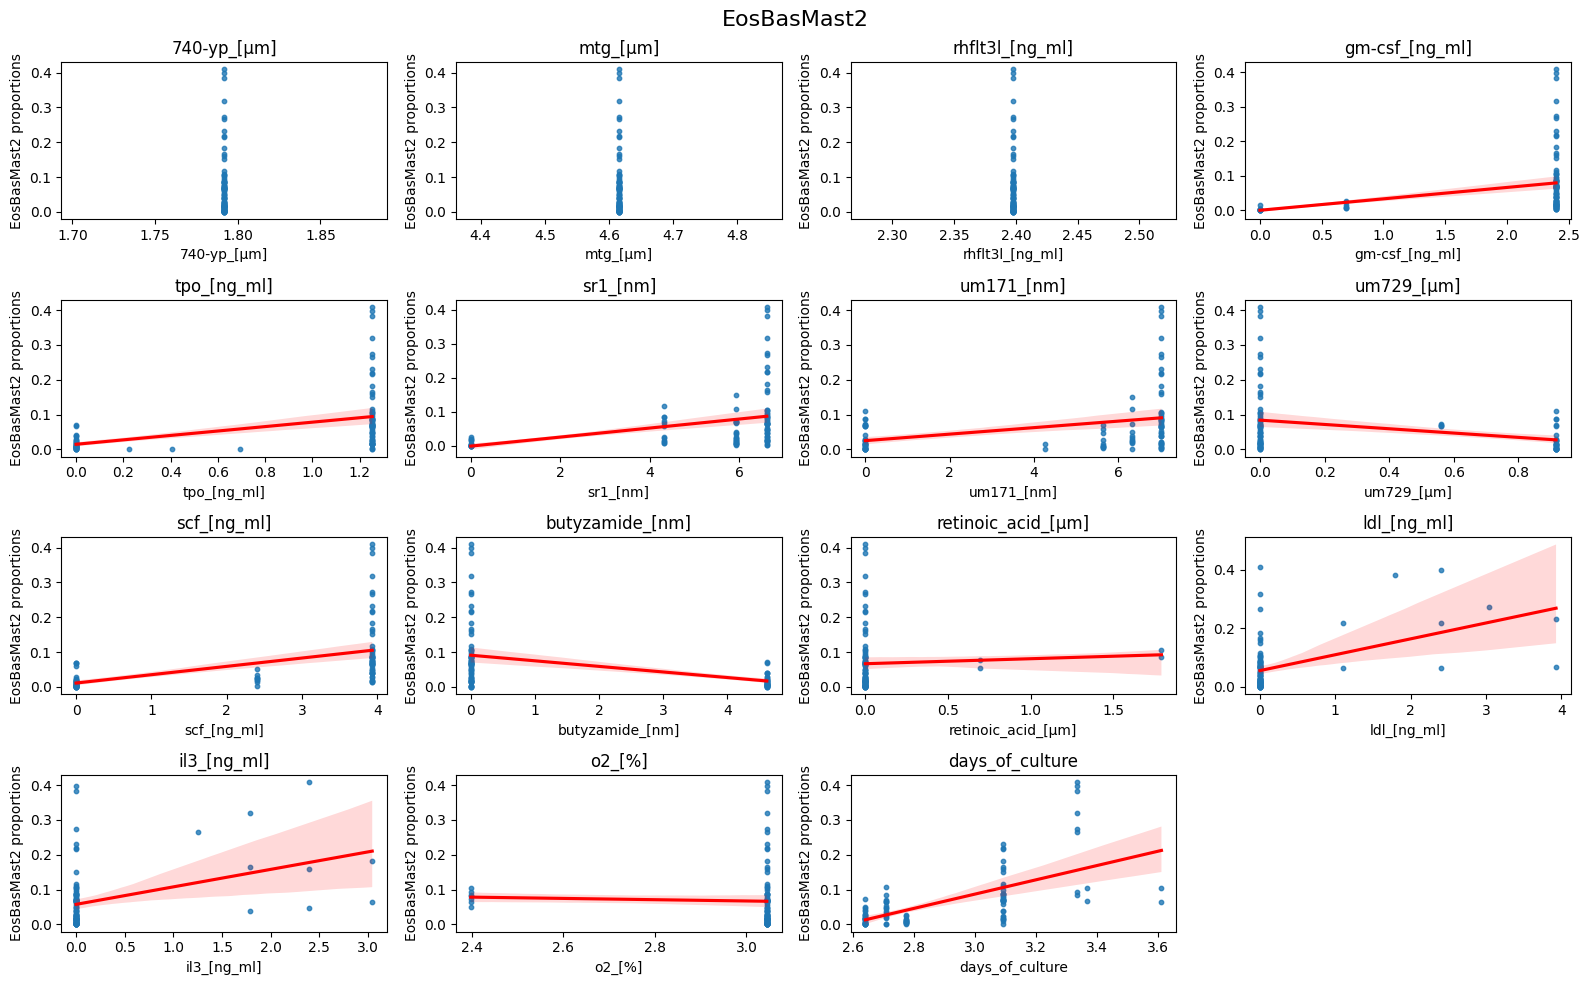

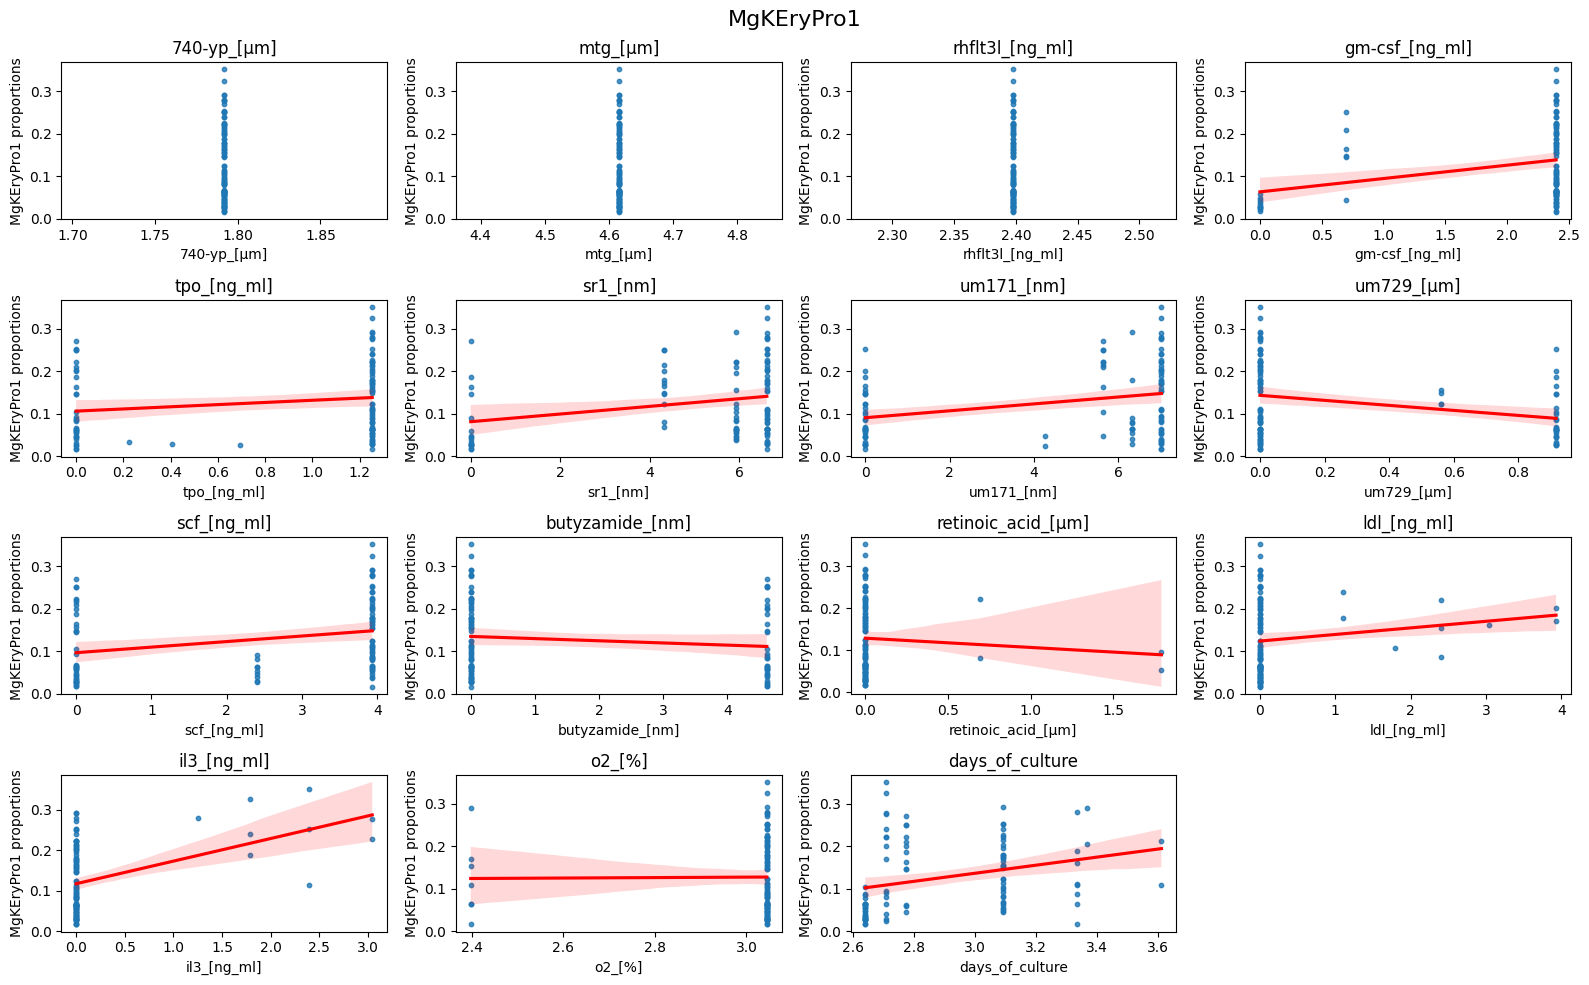

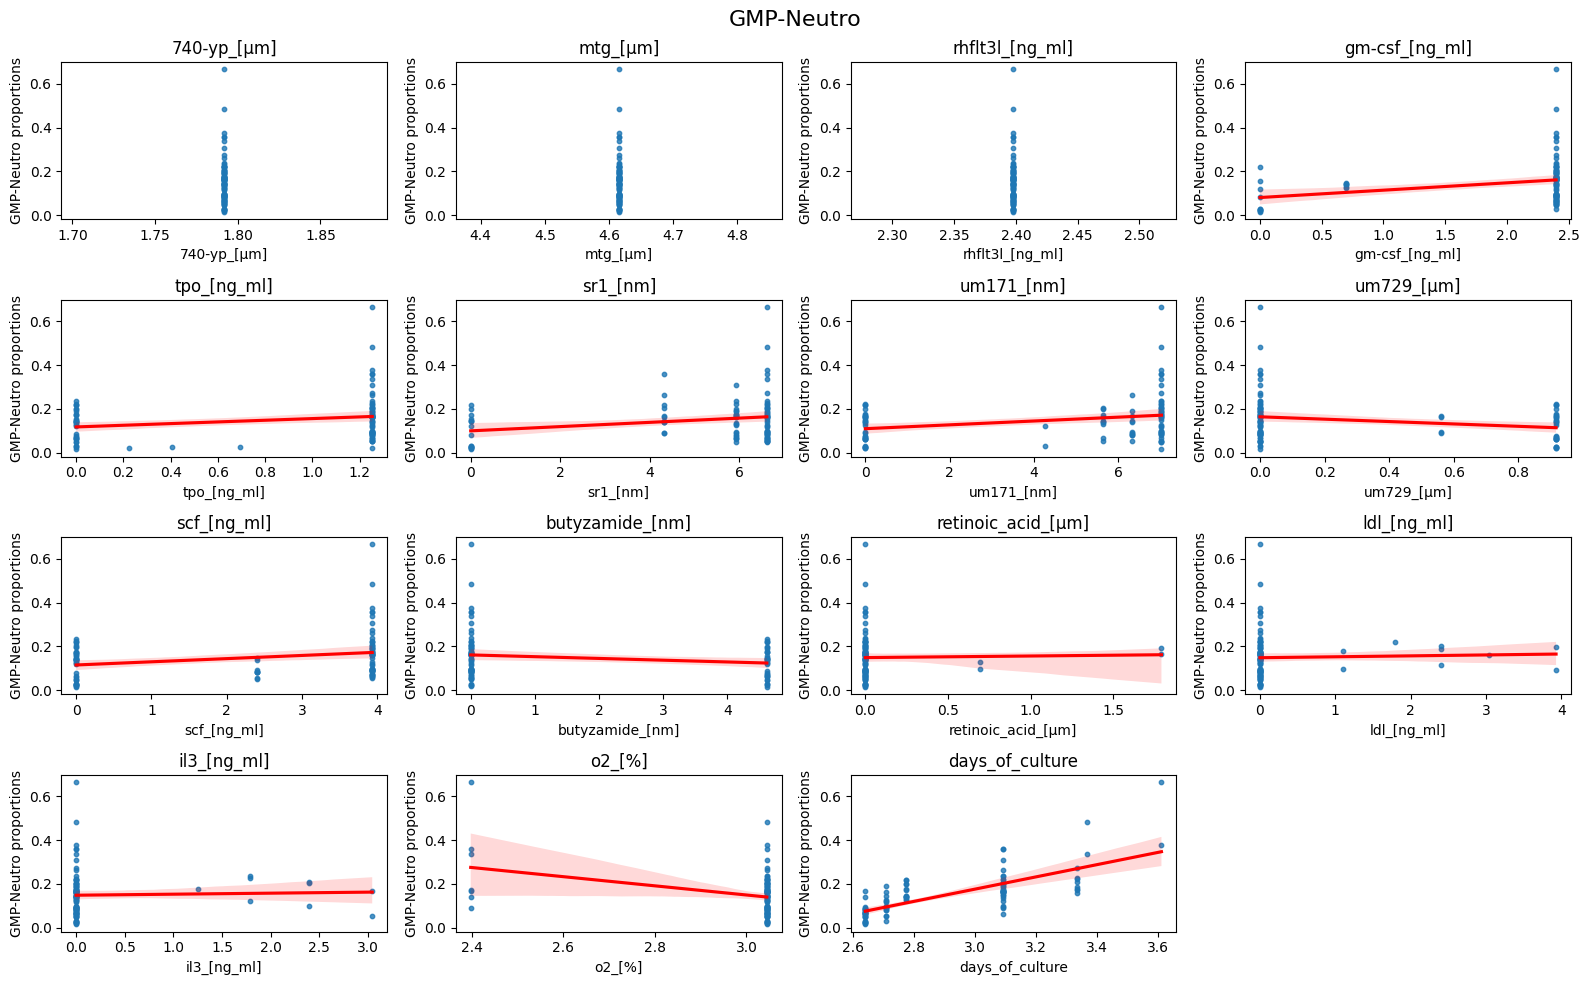

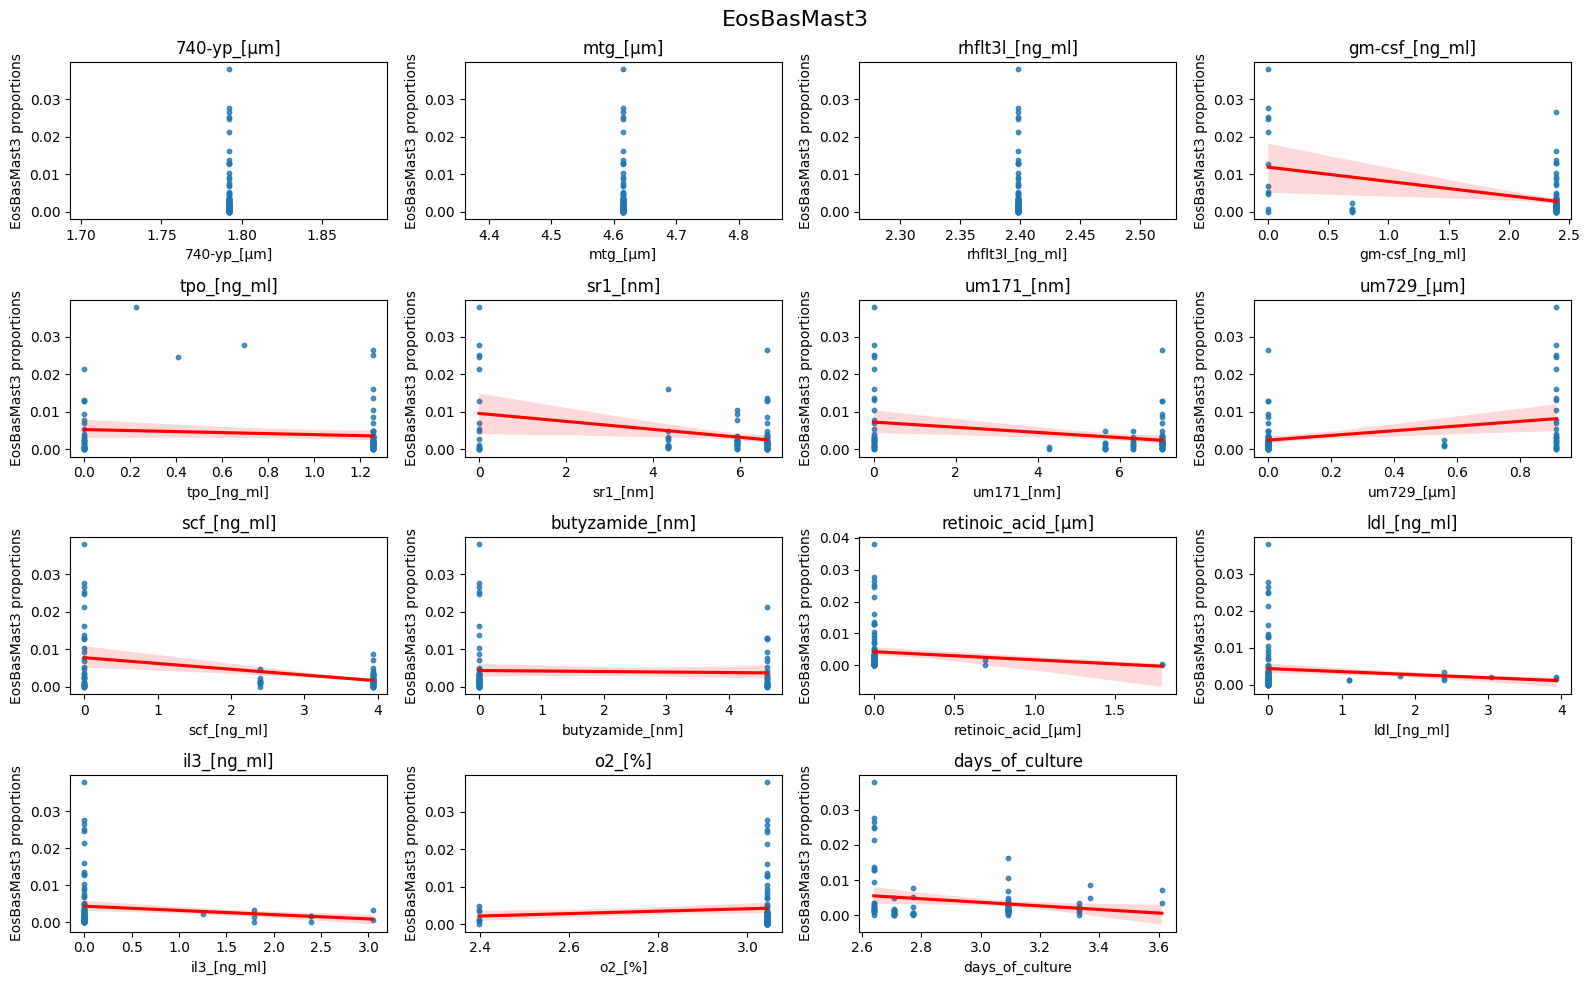

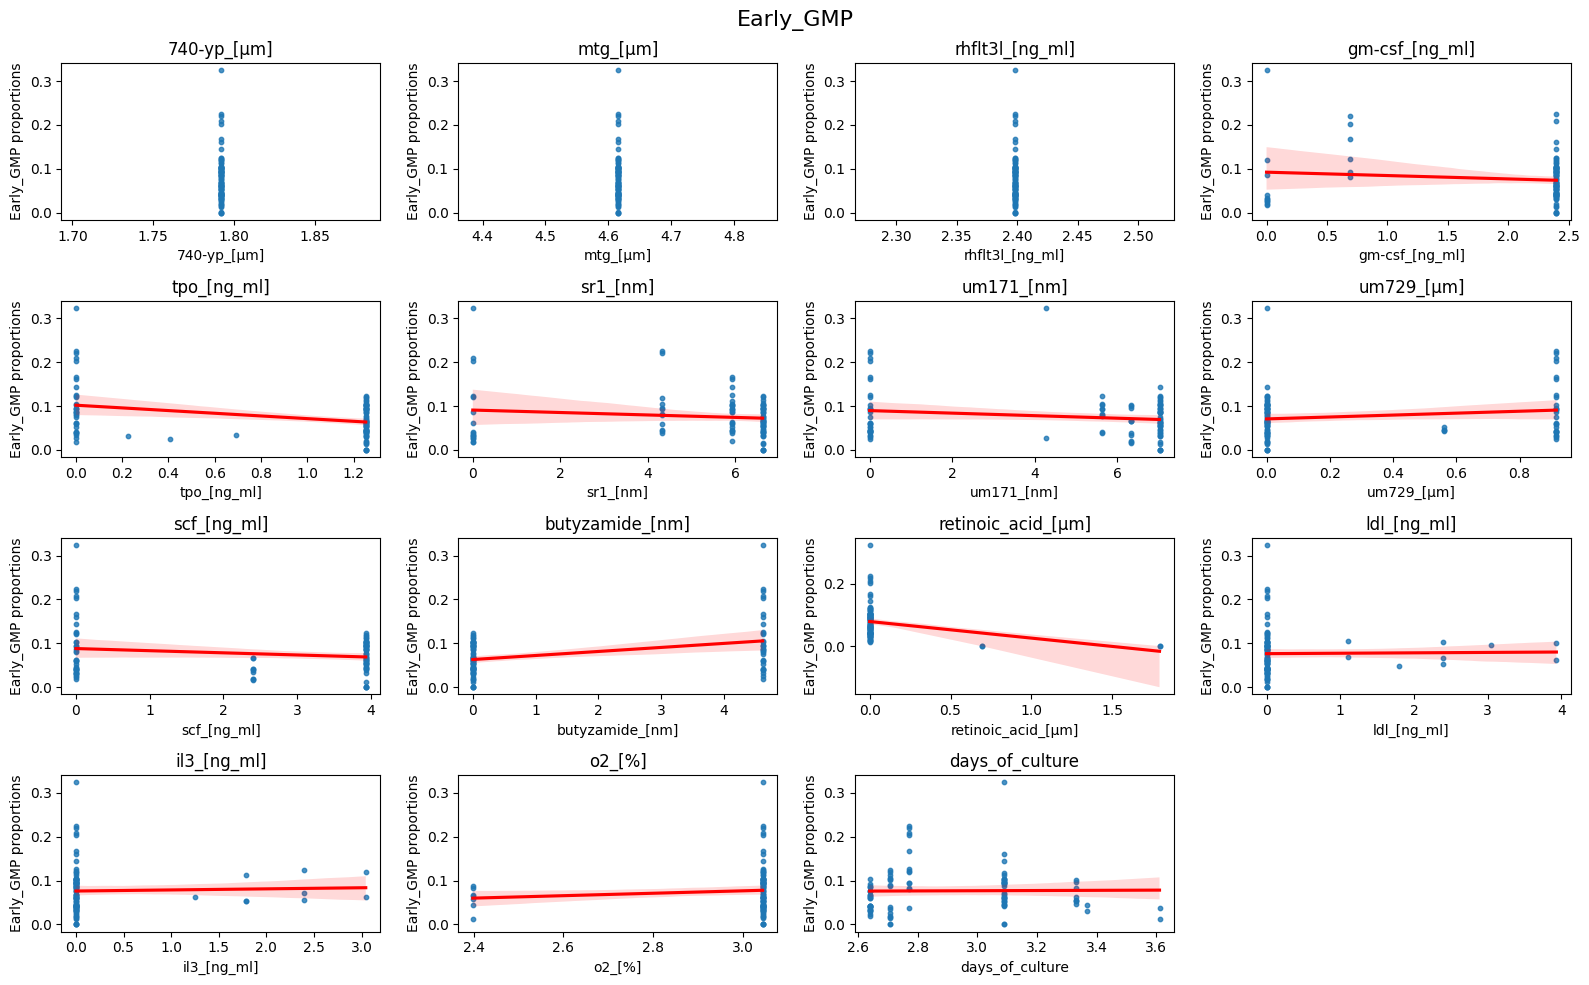

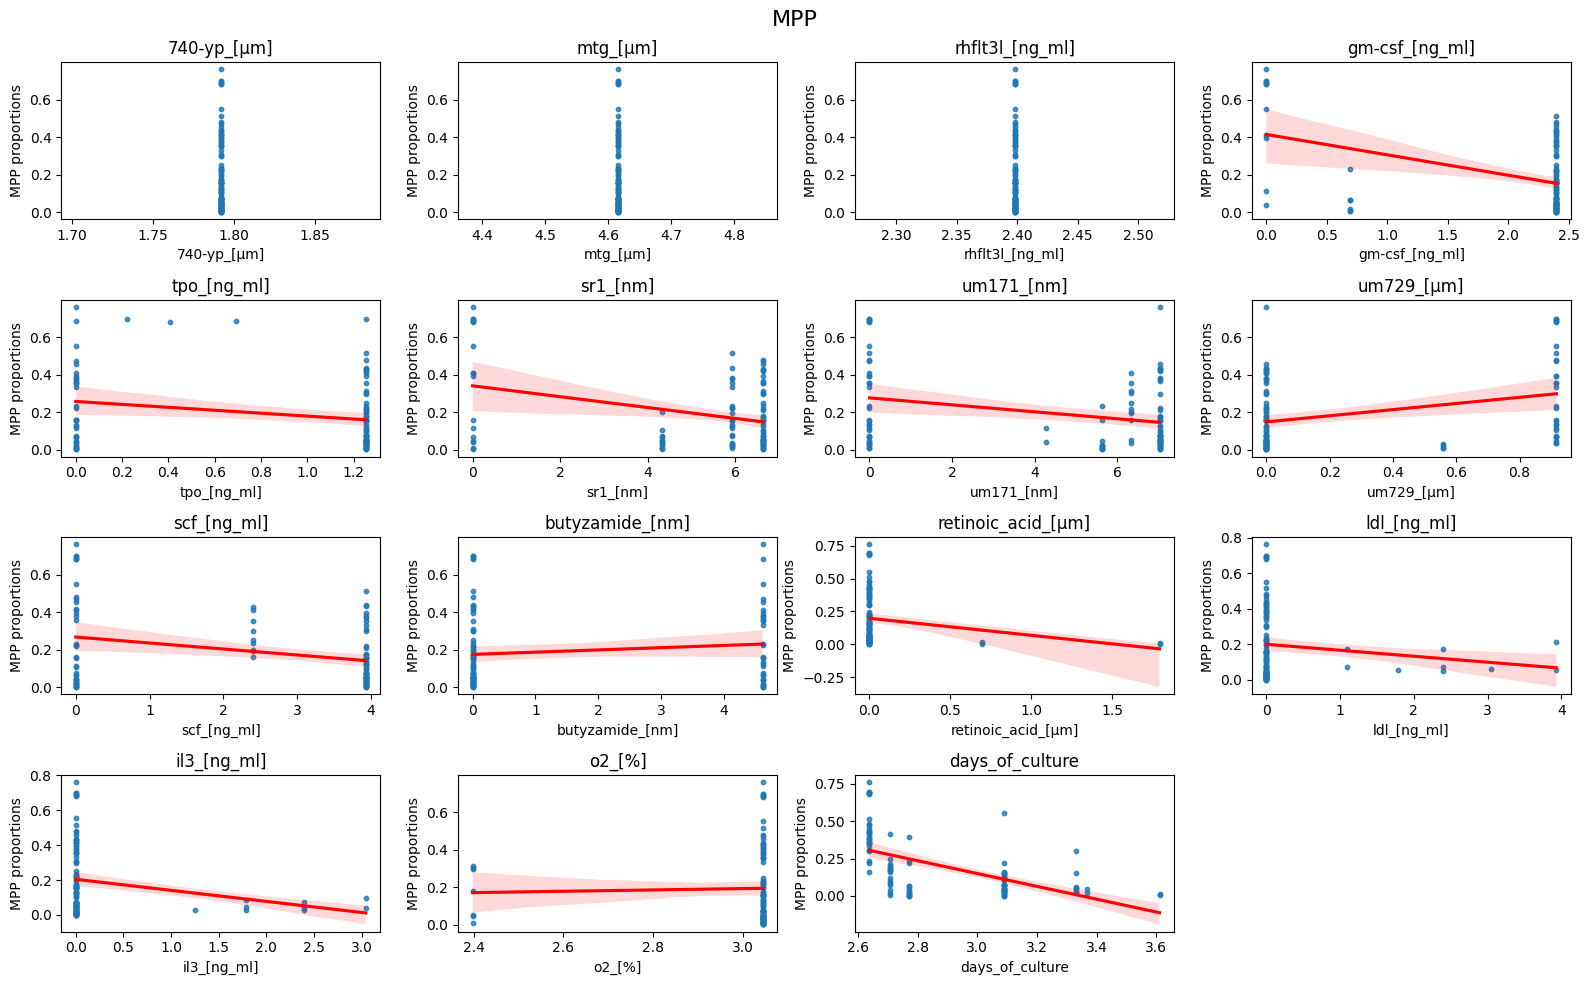

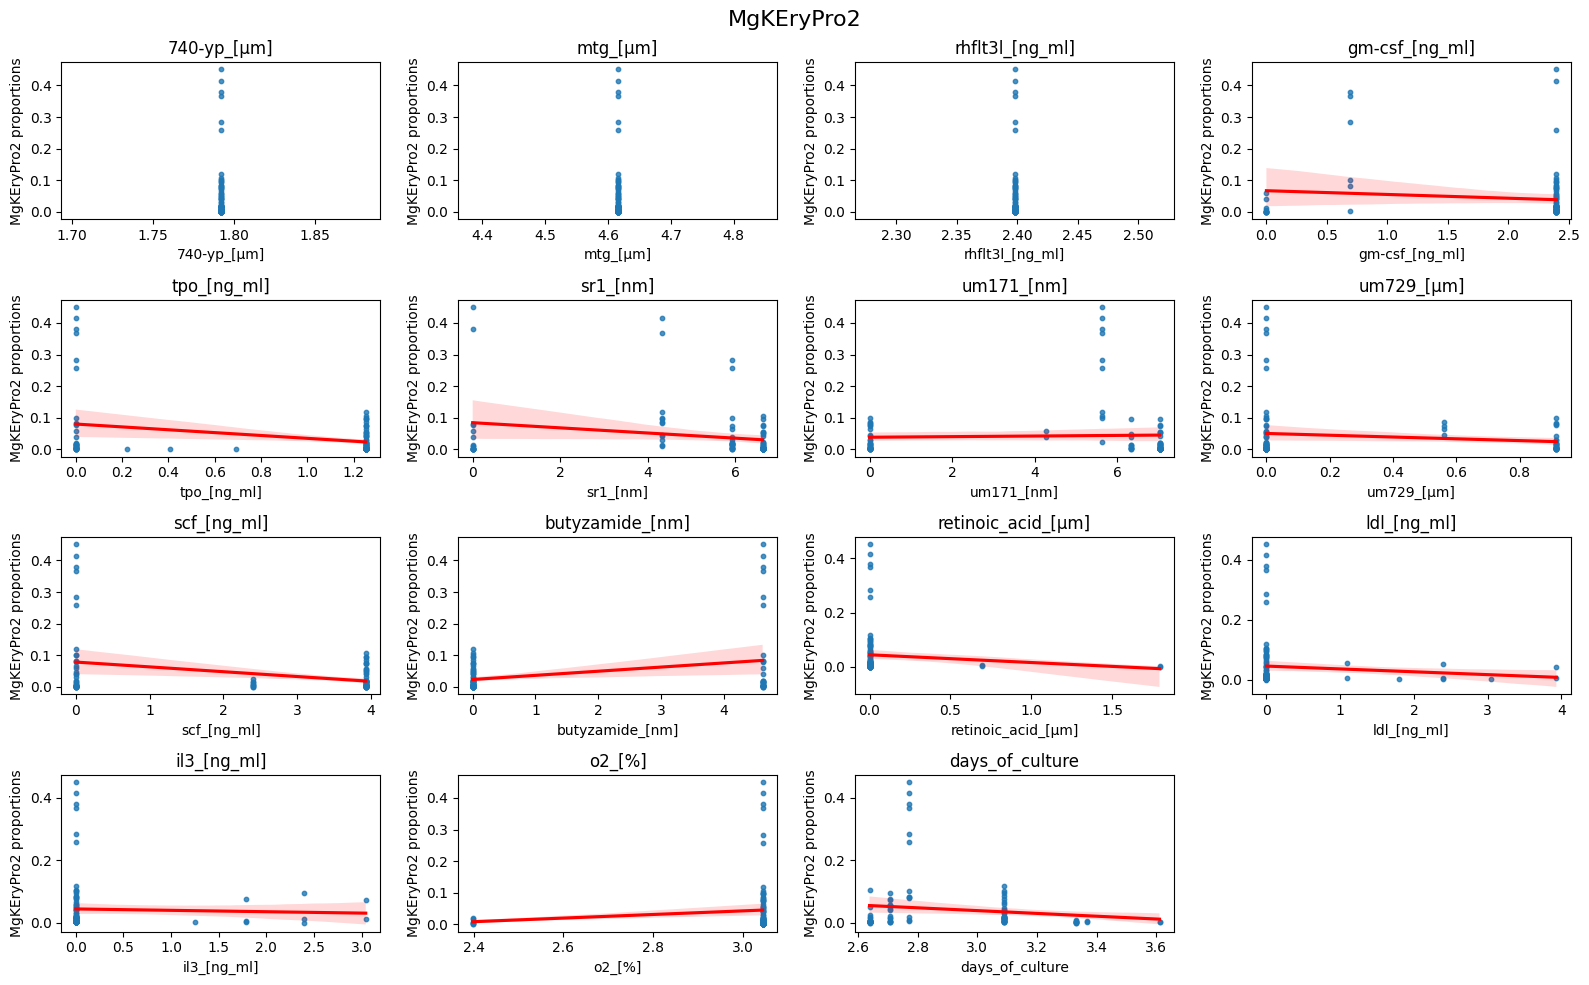

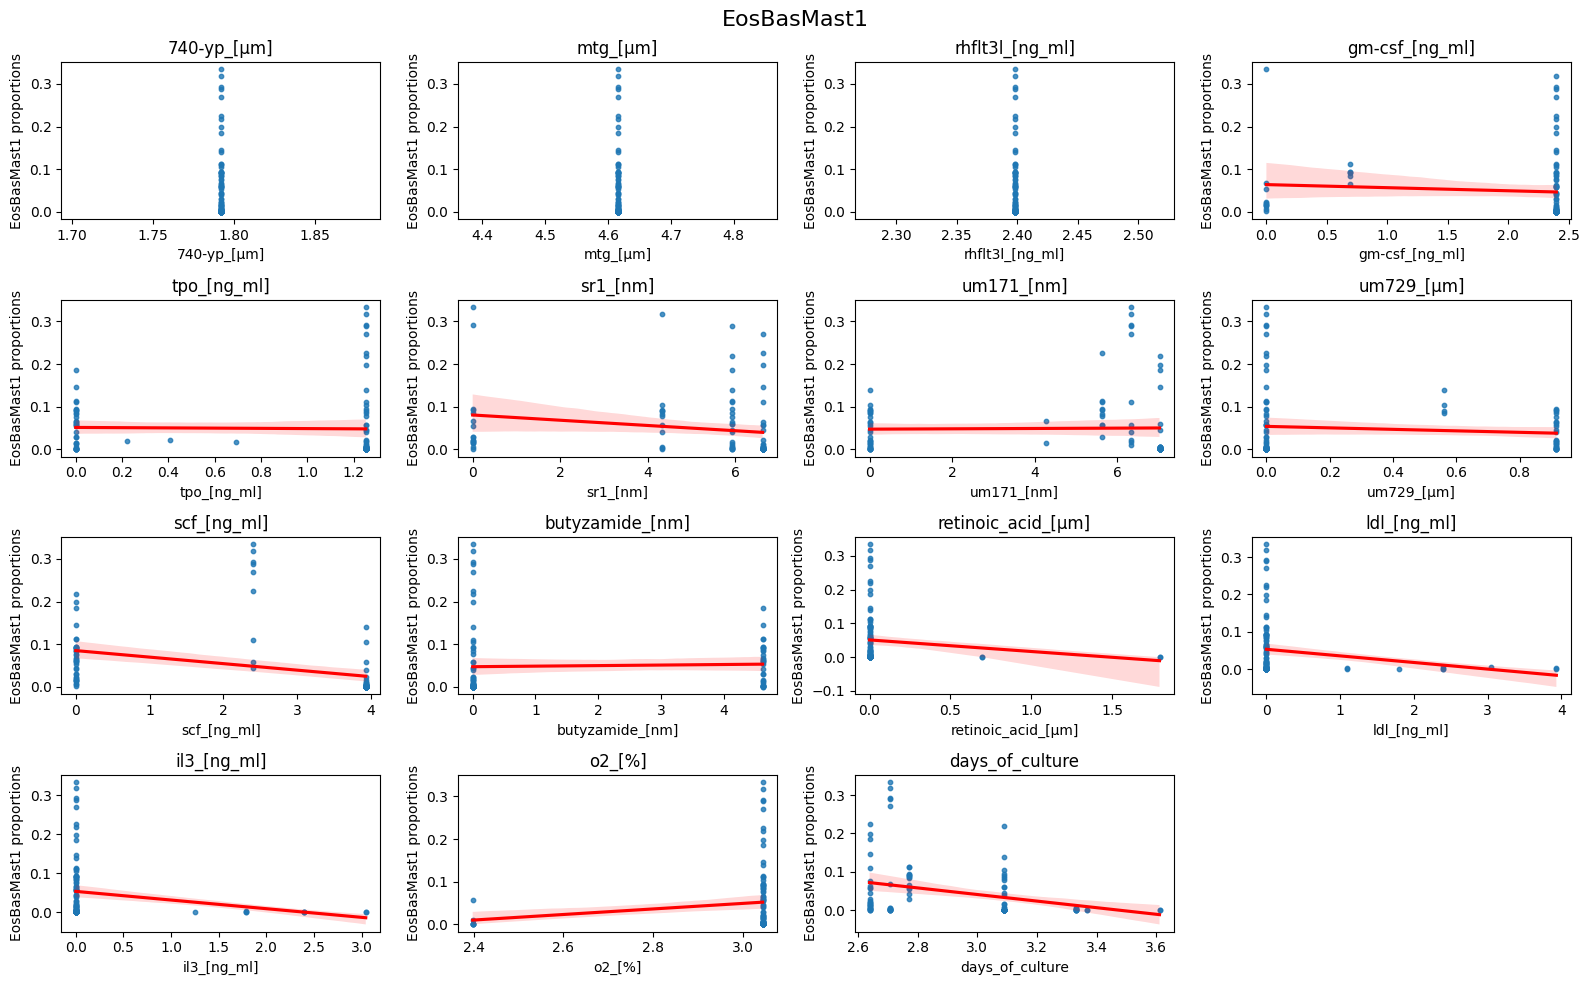

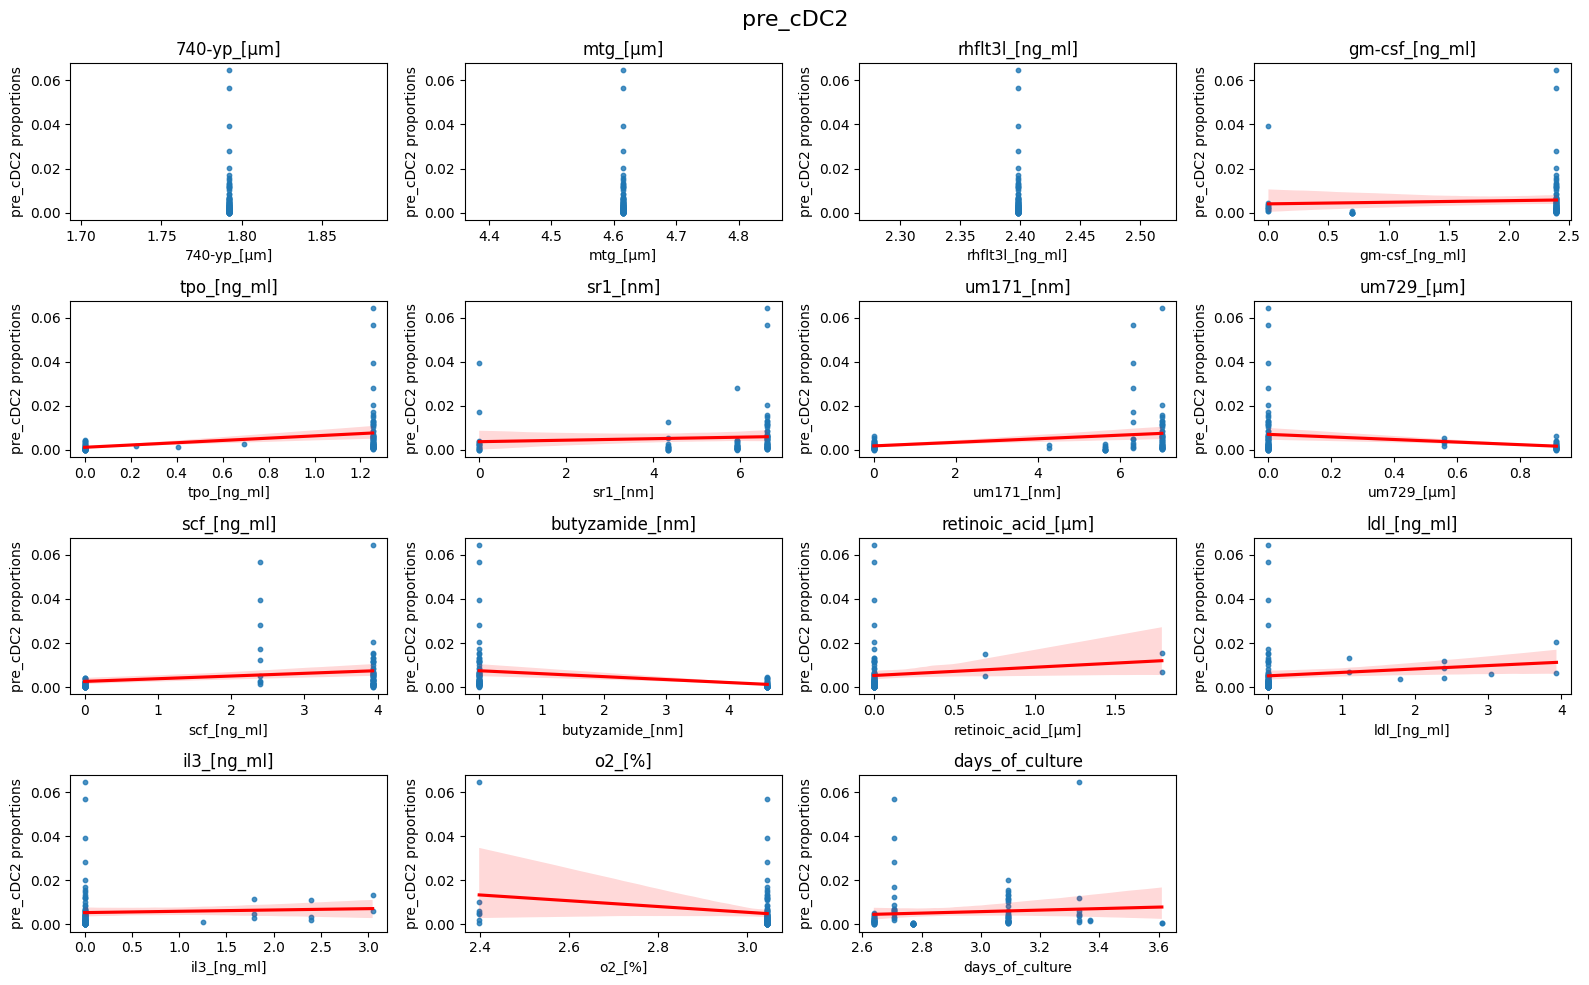

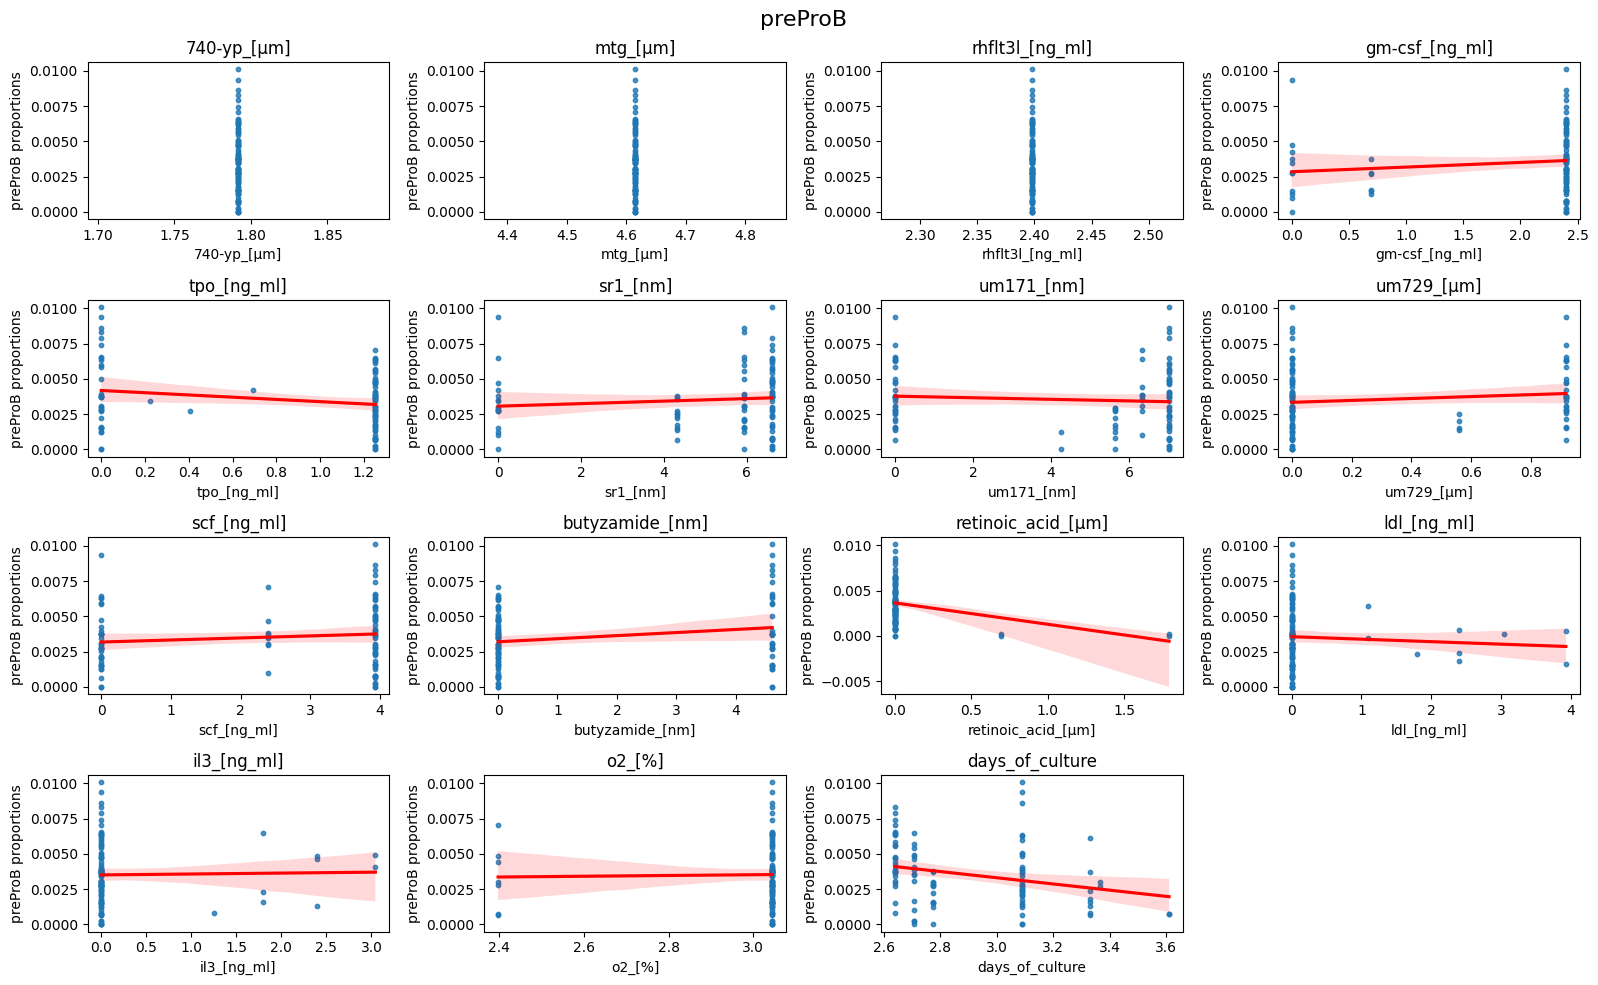

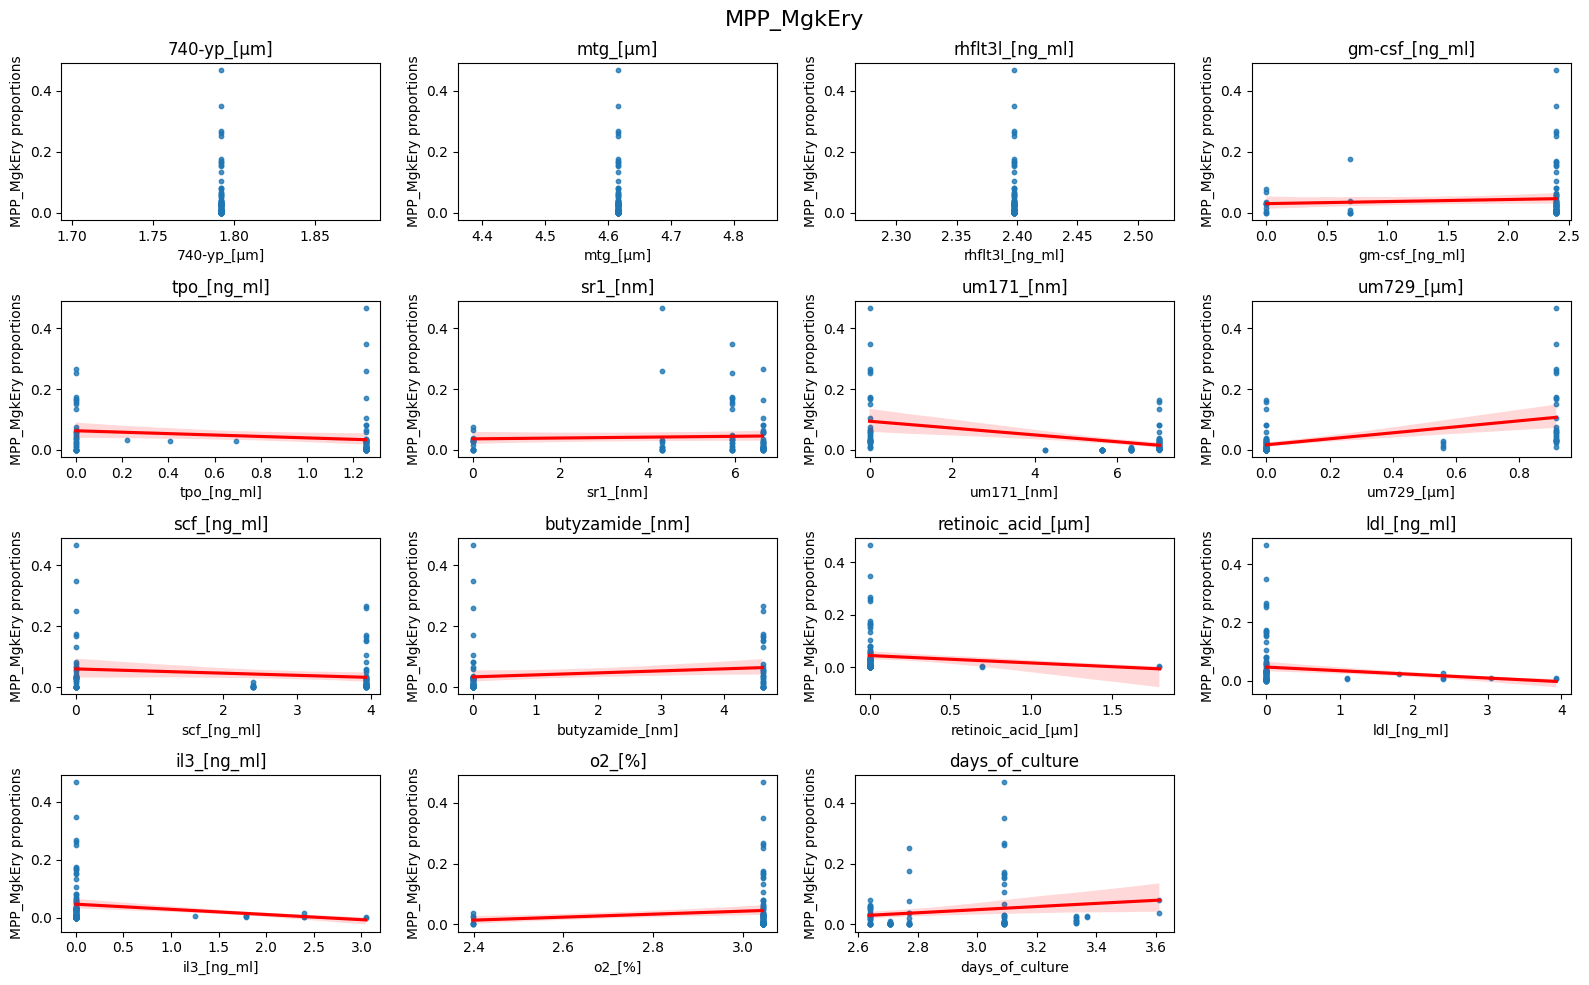

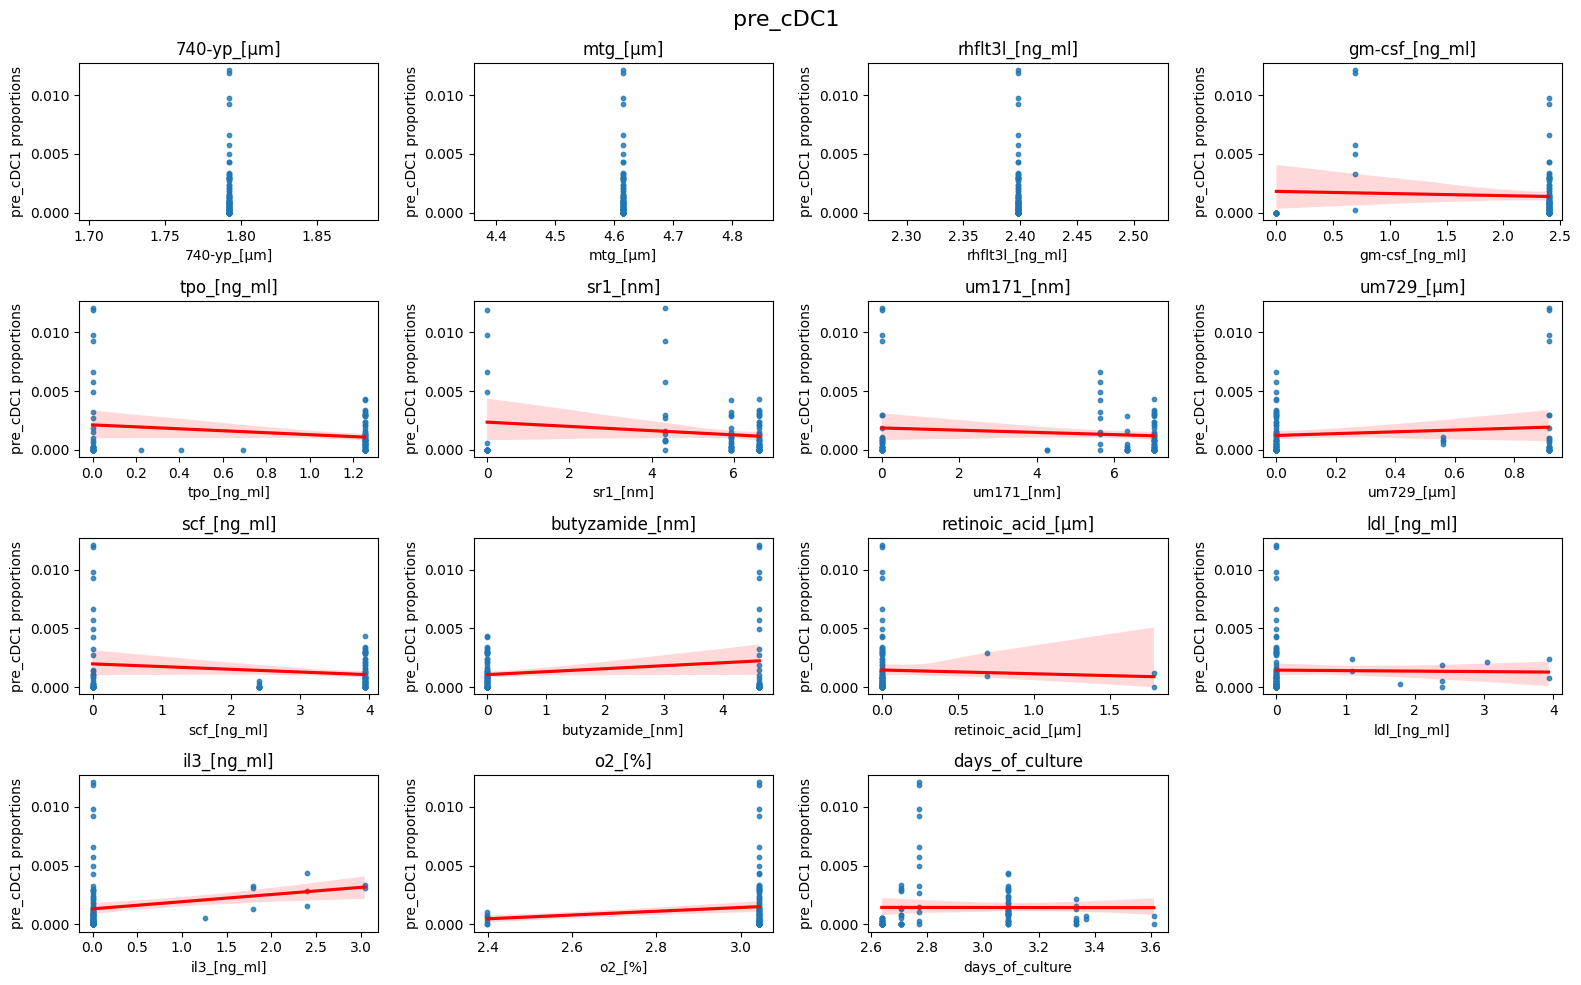

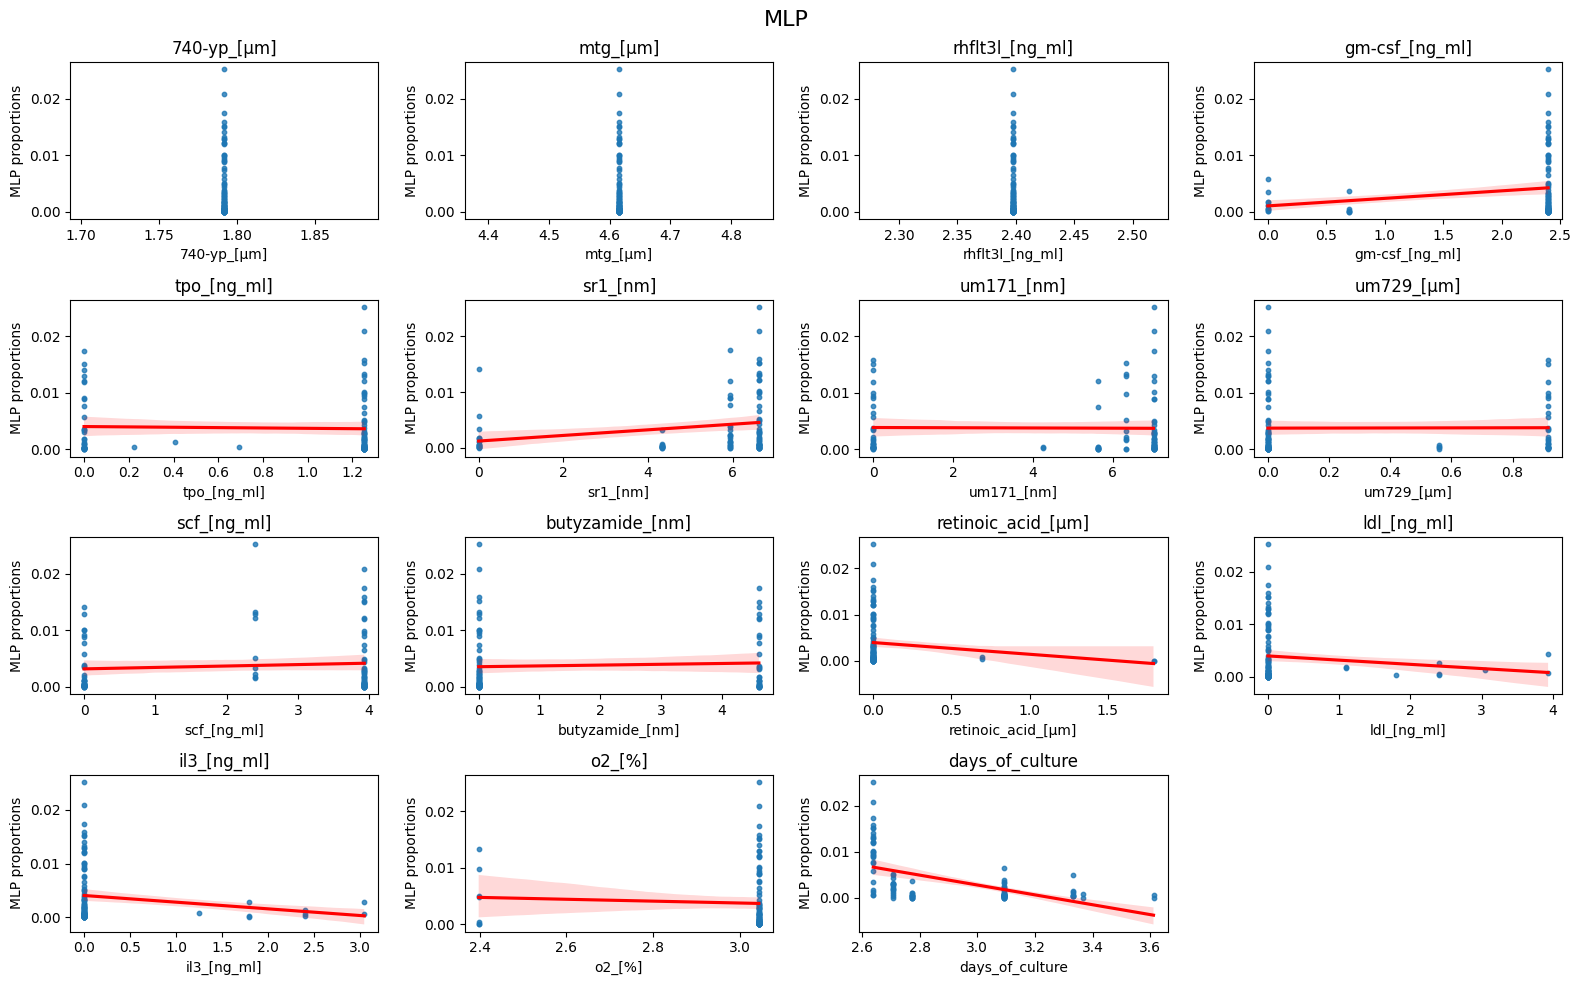

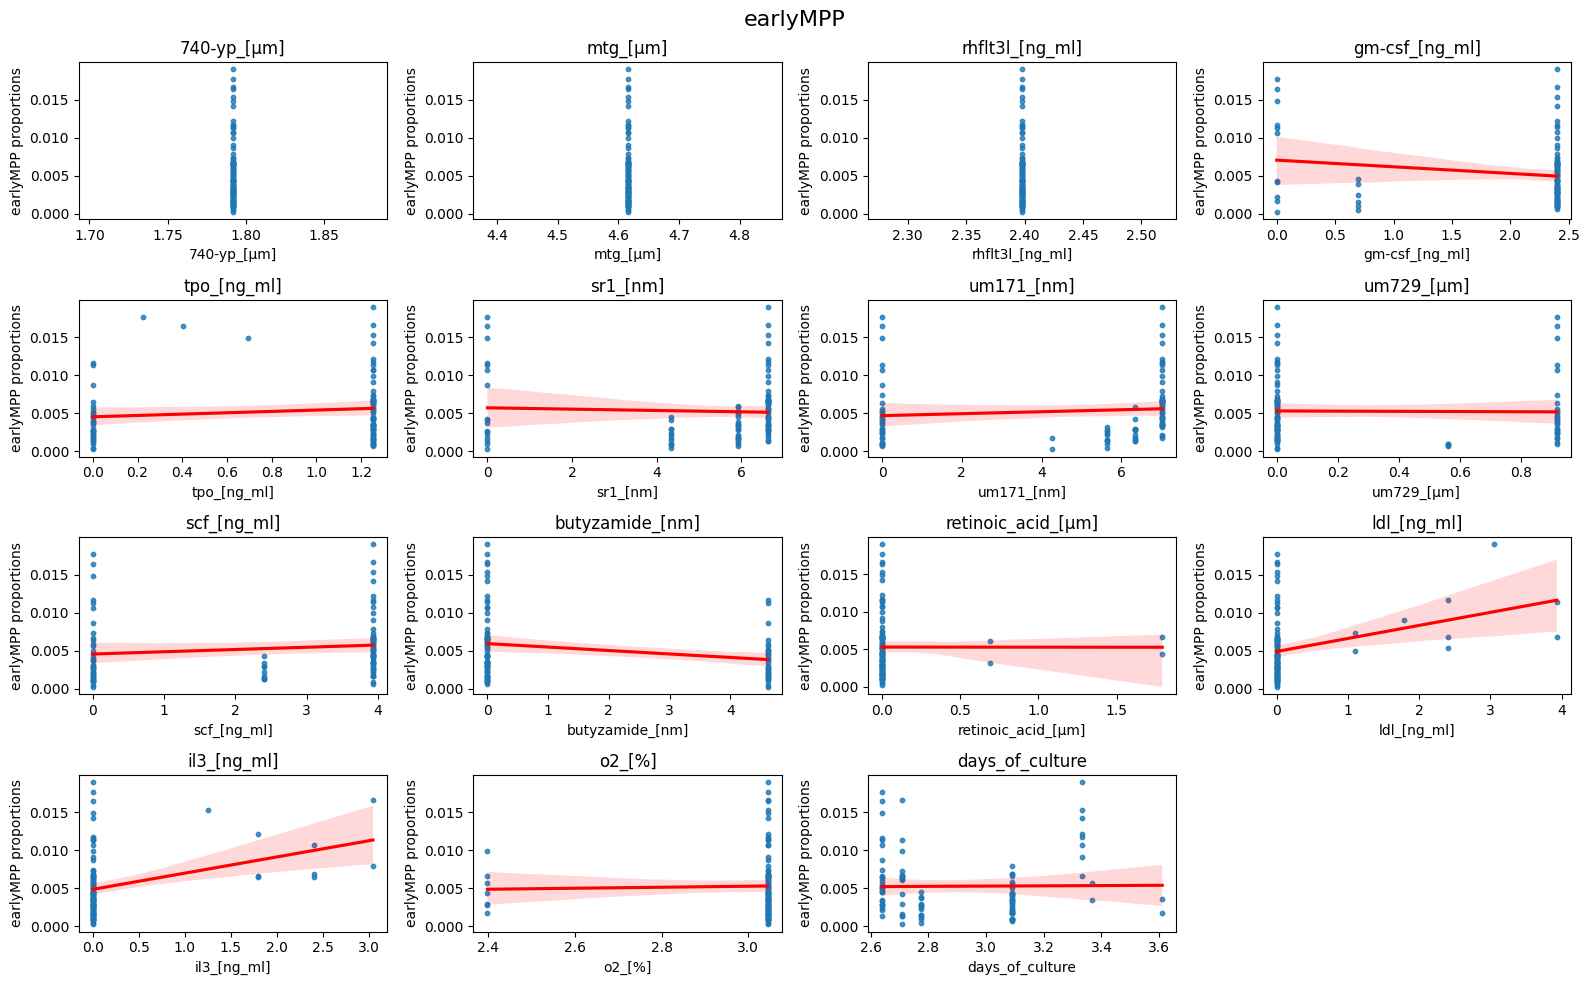

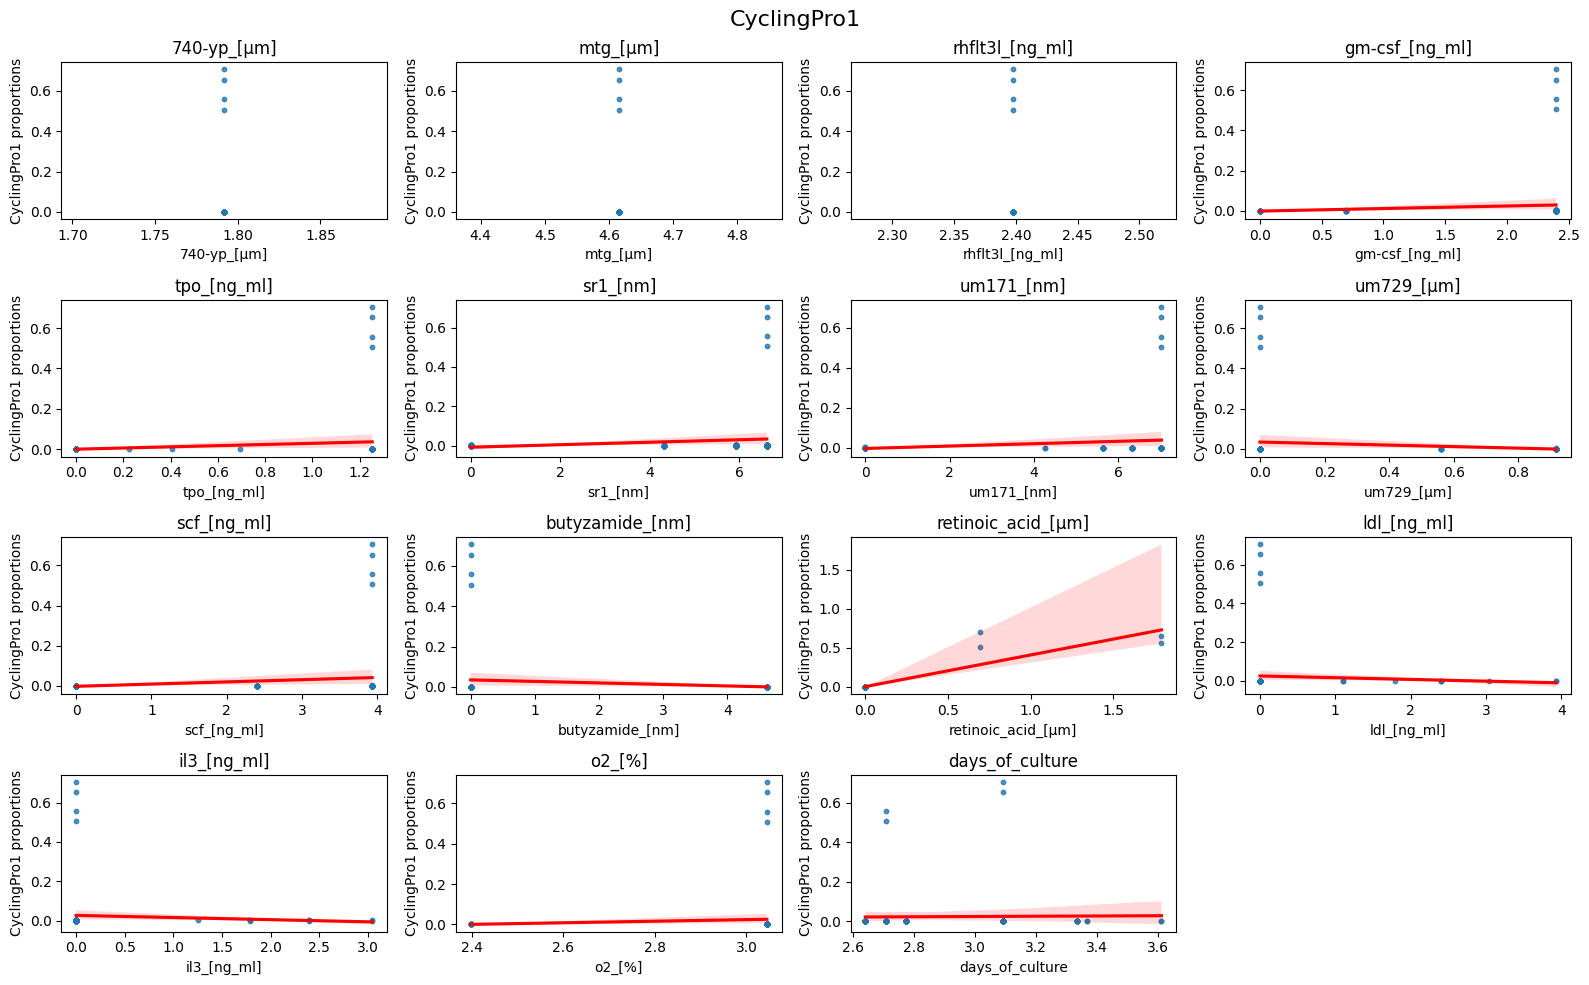

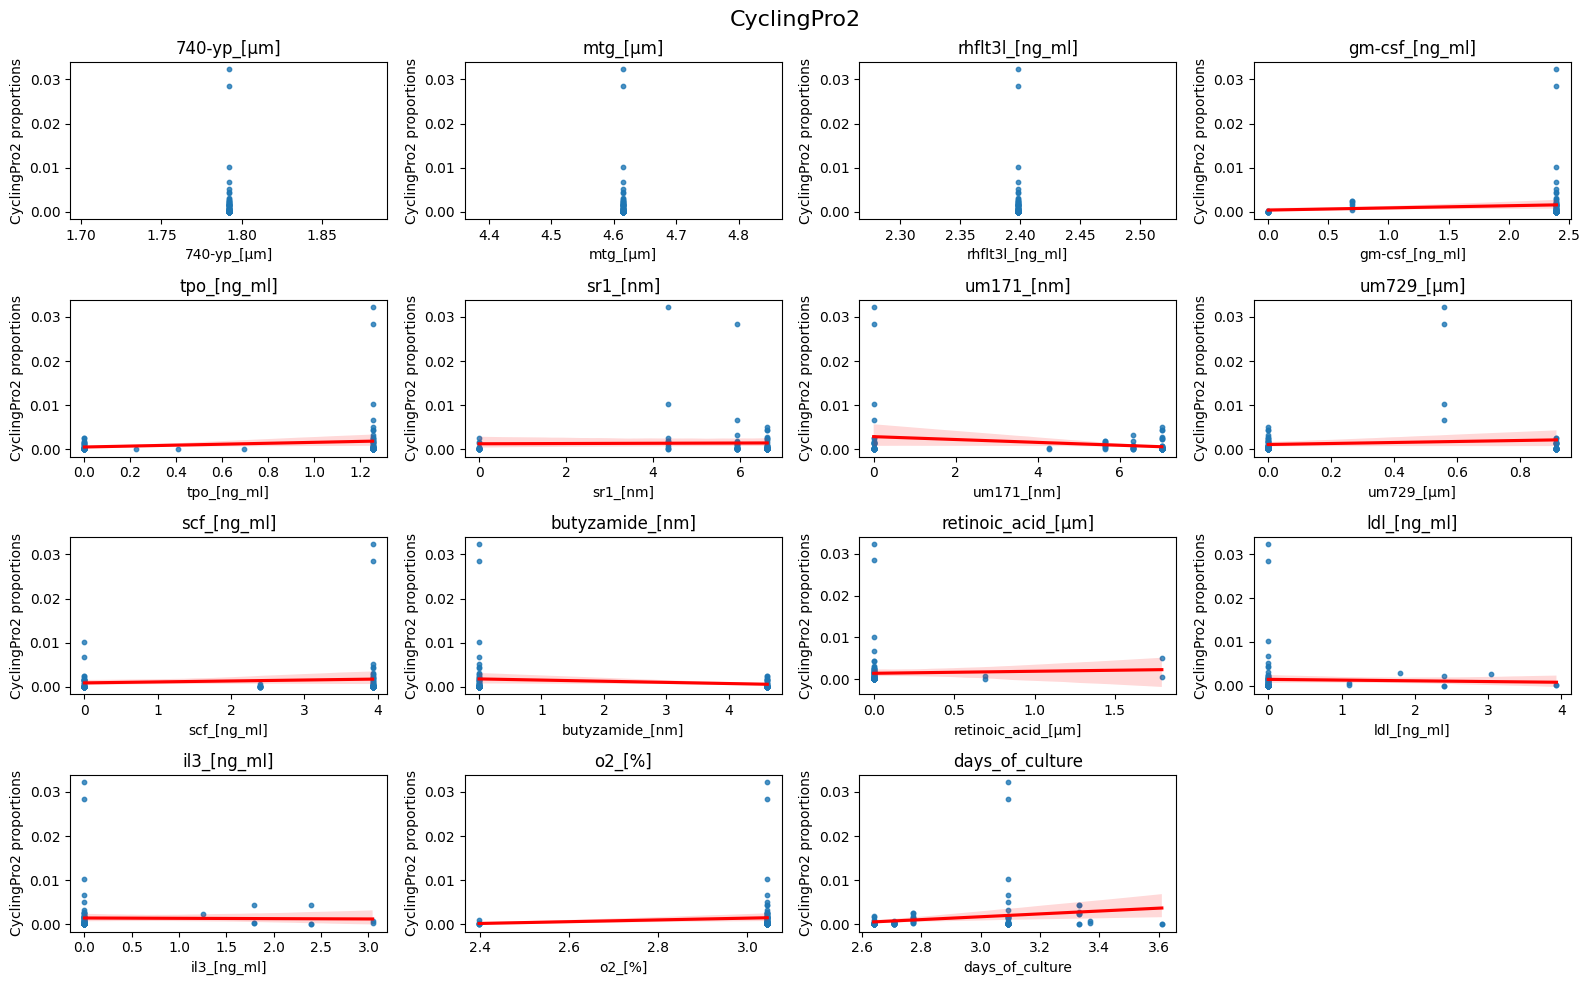

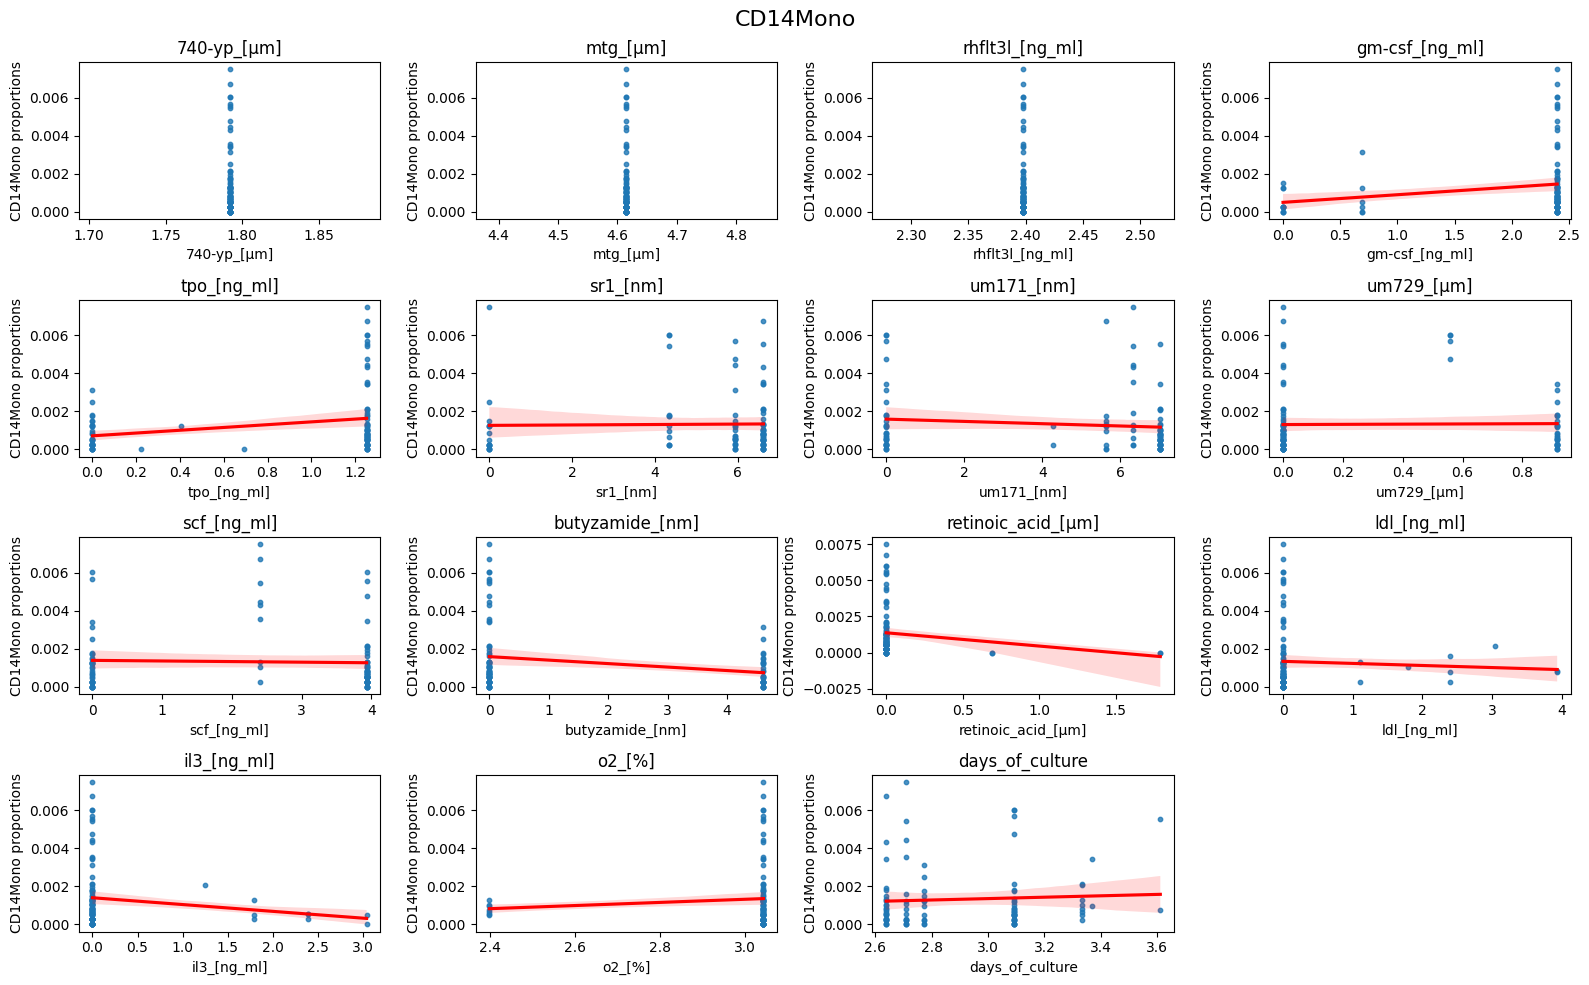

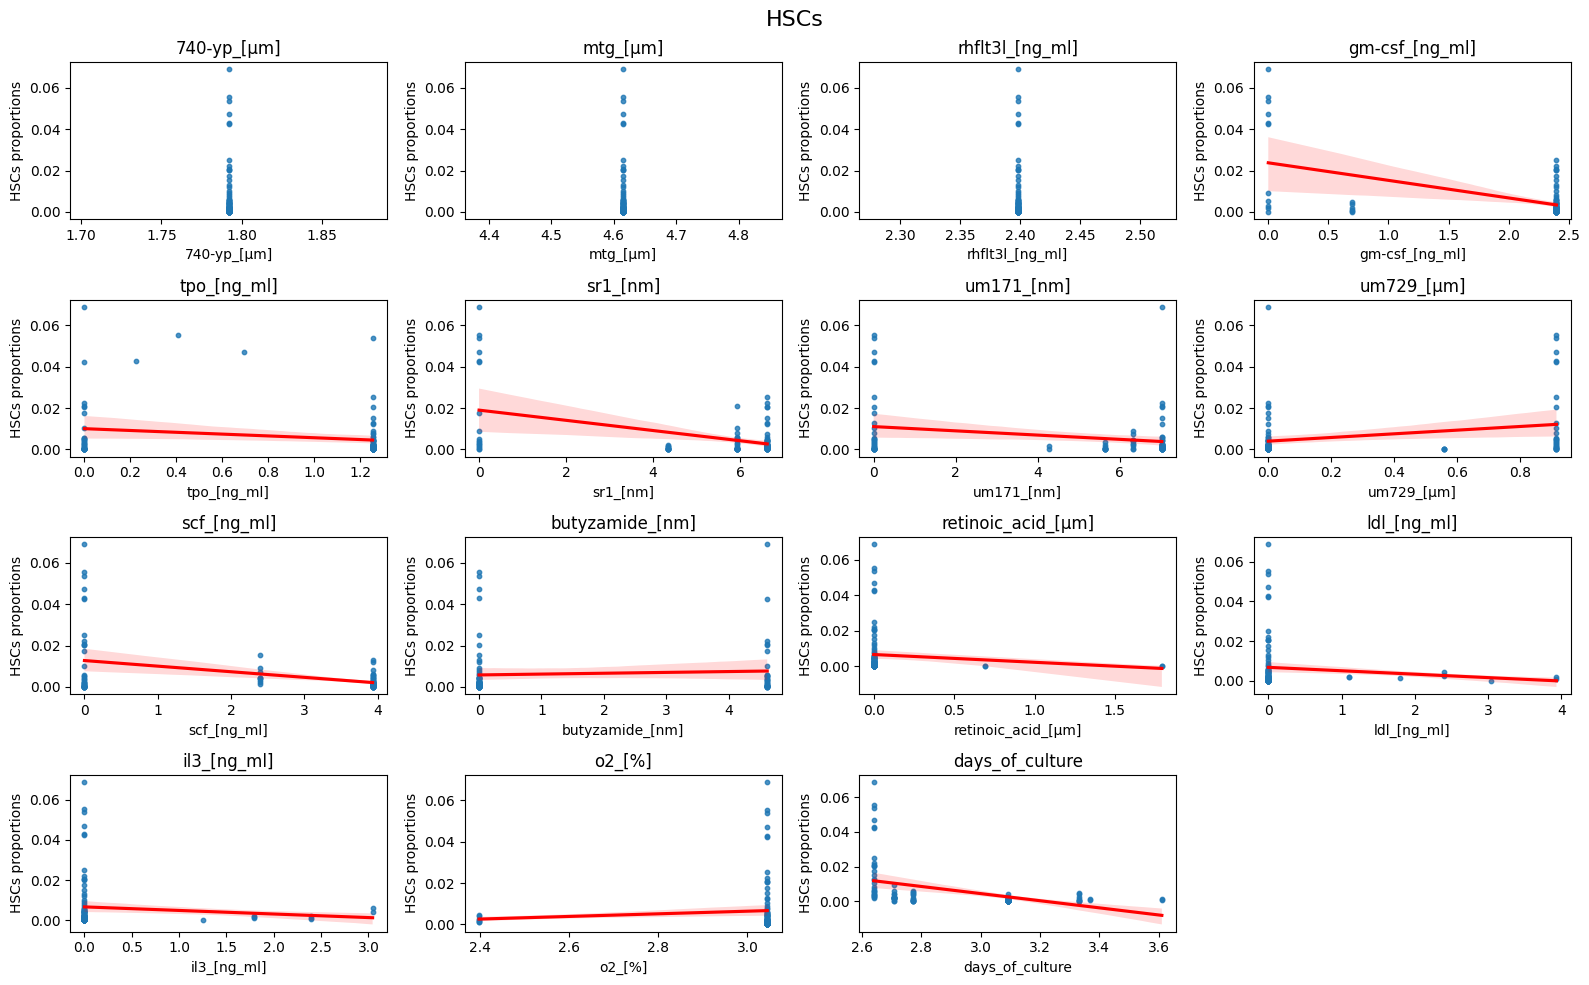

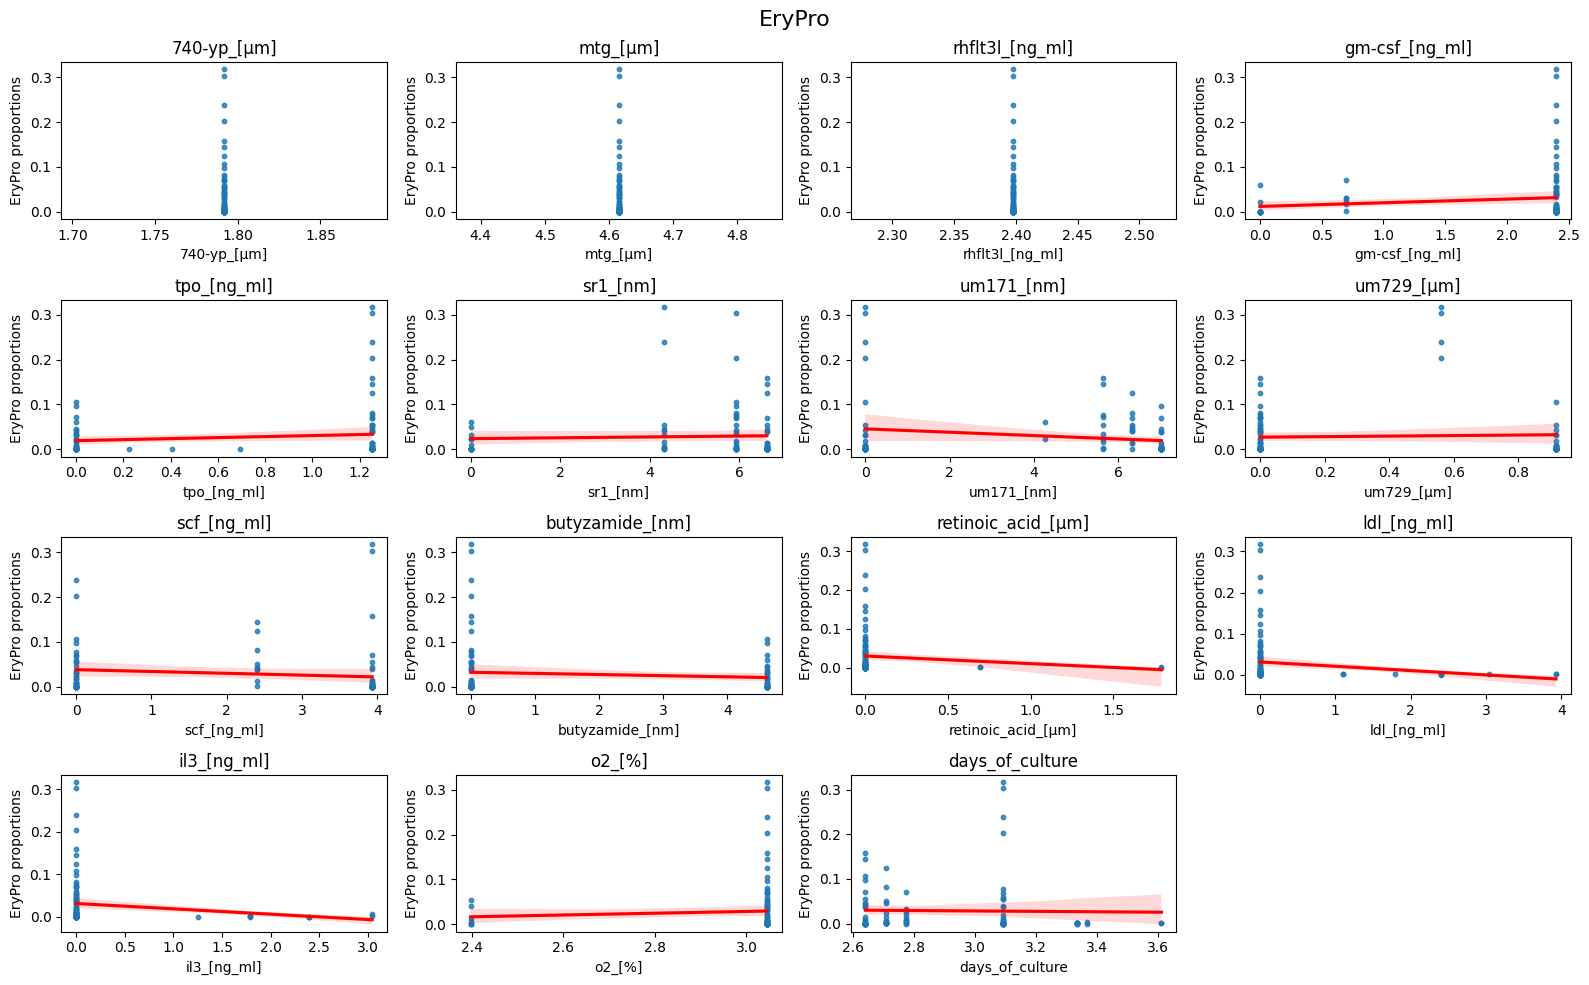

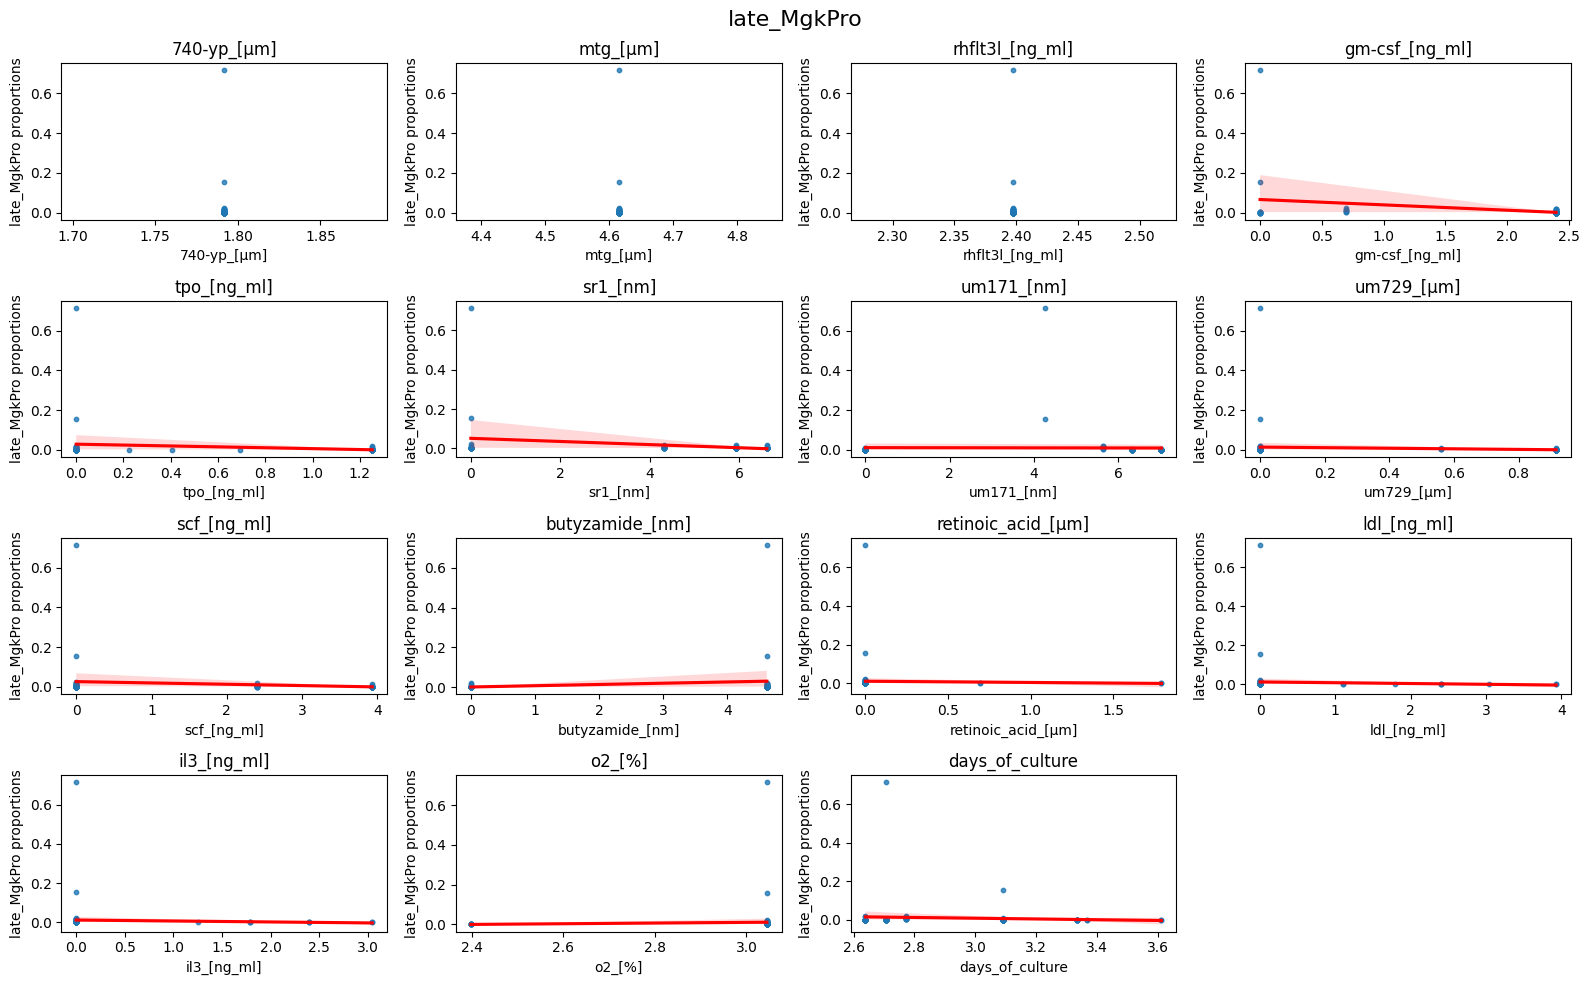

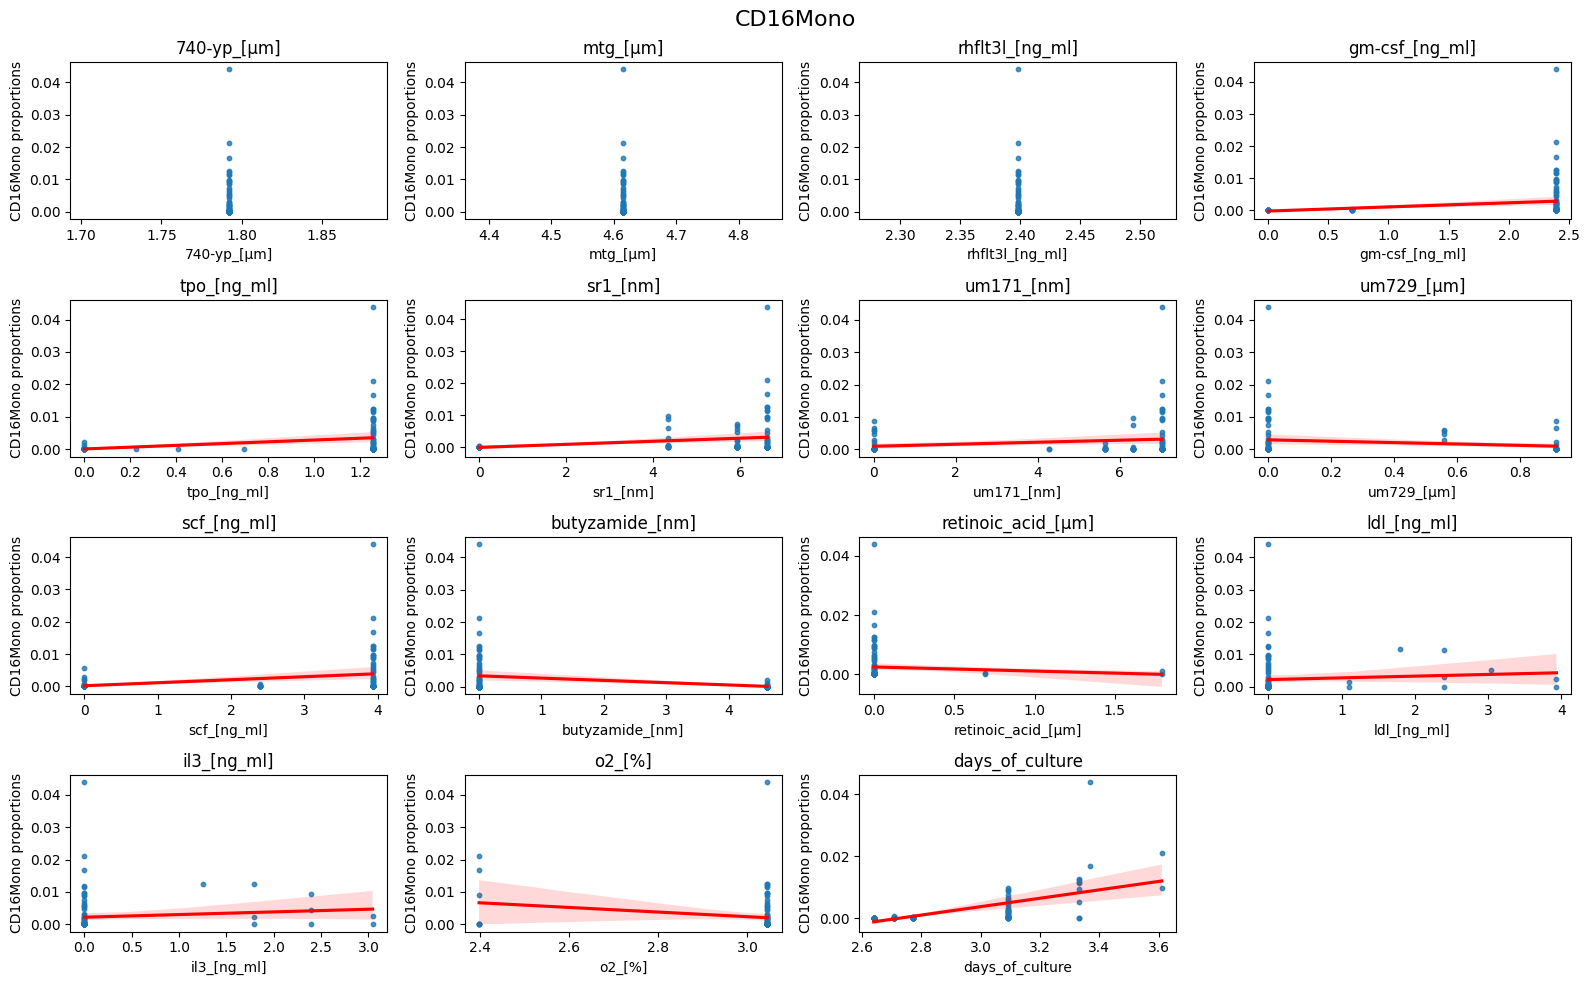

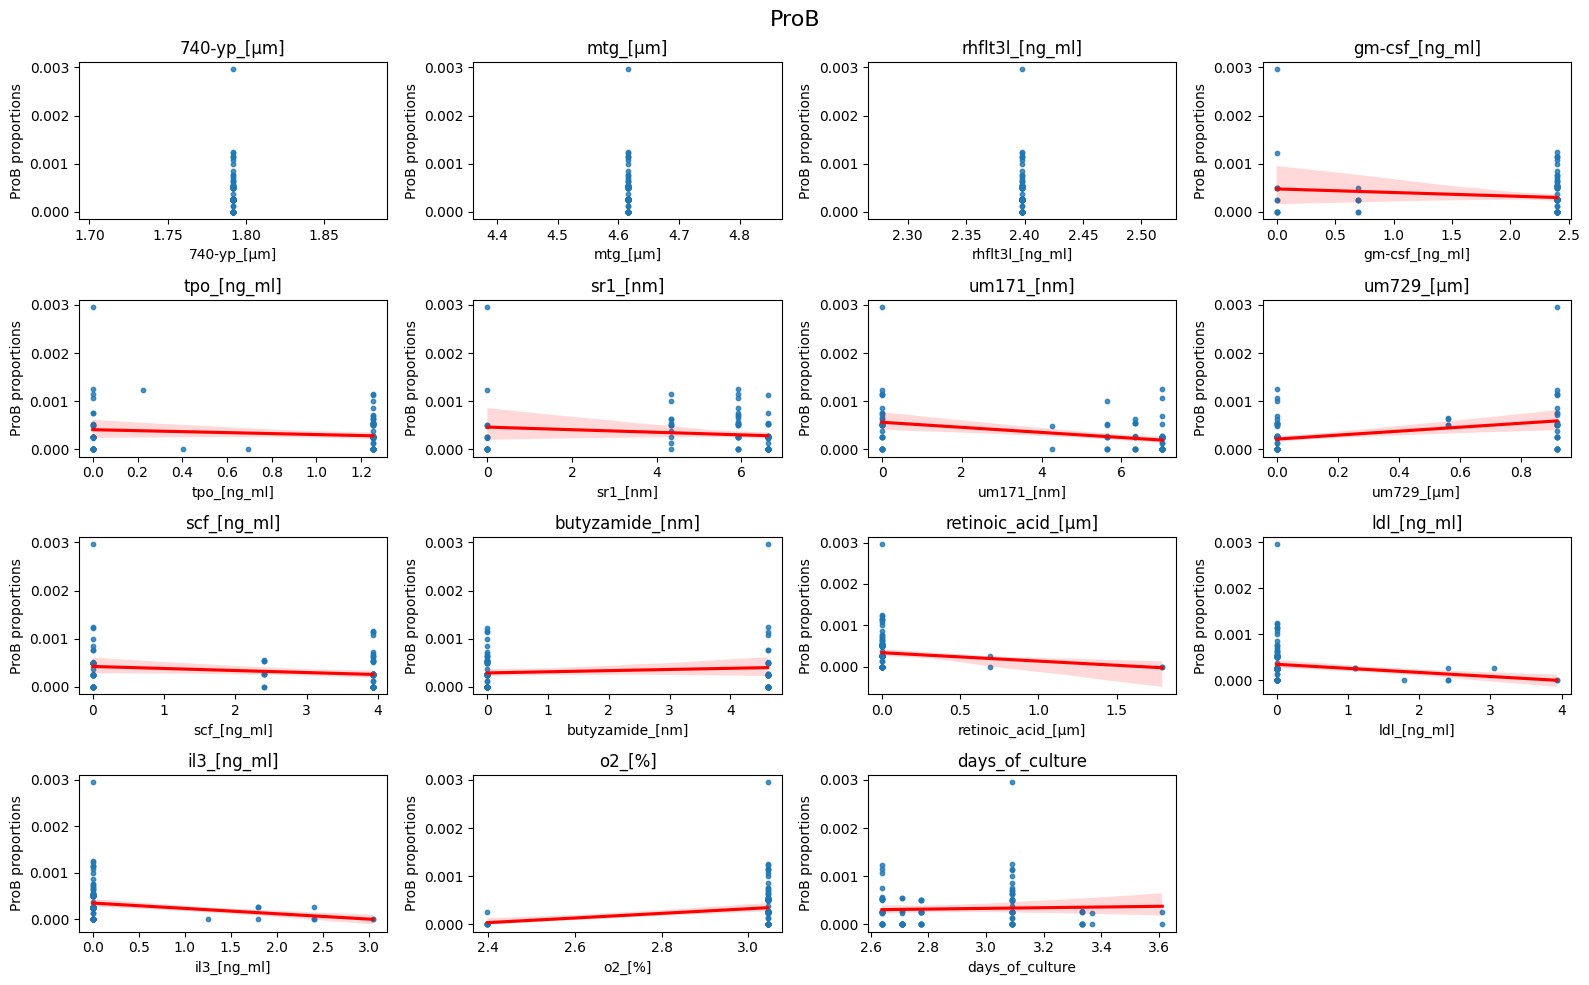

In [18]:
for cell_type in protocol_adata.obs.columns:

    to_plot_df = pd.DataFrame(protocol_adata.X)
    to_plot_df.columns = protocol_adata.var.index
    to_plot_df[f"{cell_type} proportions"] = np.array(protocol_adata.obs[cell_type])

    protocols = protocol_adata.var.index

    n_cols = 4
    n_rows = int(np.ceil(len(protocols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
    axes = axes.flatten()

    for i, protocol in enumerate(protocols):
        sns.regplot(
            data=to_plot_df,
            x=protocol,
            y=f"{cell_type} proportions",
            ax=axes[i],
            scatter_kws={"s": 10},
            line_kws={"color": "red"}
        )
        axes[i].set_title(protocol)

    for j in range(len(protocols), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"{cell_type}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [19]:
adata_argmax.obs.drop(["cell_type"], axis=1).max(0)

LMPP-CLP       0.297328
GMP_cycling    0.218654
EosBasMast2    0.408742
MgKEryPro1     0.351799
GMP-Neutro     0.665340
EosBasMast3    0.037866
Early_GMP      0.324344
MPP            0.761563
MgKEryPro2     0.450625
EosBasMast1    0.334009
pre_cDC2       0.064441
preProB        0.010091
MPP_MgkEry     0.466726
pre_cDC1       0.012088
MLP            0.025214
earlyMPP       0.018999
CyclingPro1    0.704545
CyclingPro2    0.032233
CD14Mono       0.007501
HSCs           0.068761
EryPro         0.316938
late_MgkPro    0.715066
CD16Mono       0.043888
ProB           0.002957
dtype: float64

## Full data 

In [ ]:
# full_data =  sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad")

In [ ]:
# sc.tl.pca(full_data)
# sc.pp.neighbors(full_data)
# sc.tl.umap(full_data)

In [296]:
# adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/dataset_unmix8/ds_HID01_logicle_100k_UMAP_ann.h5ad")

In [295]:
# for p in protocol_columns:
#     print(p)
#     print(np.array(adata.obs[p].unique()))
#     print()